# **Project Name - yes bank stock price prediction ML project **    



##### **Project Type**    - Regression
##### **Contribution**    - Individual 
##### **Team Member 1 - Ankush Chaudhari **

# **Project Summary -**

The **YES BANK Stock Price Prediction** project focuses on applying machine learning techniques to predict the closing price of YES BANK using historical stock-market data. The project was developed as a regression-based machine learning solution, where the closing price is treated as a continuous target variable. The dataset contains **185 monthly observations** covering the period from **July 2005 to November 2020**, with information on Date, Open, High, Low, and Close prices.

The project began with **data preprocessing and exploratory data analysis (EDA)** to understand the structure, quality, and characteristics of the dataset. The dataset was checked for missing values, duplicate records, data types, and potential outliers. No missing values were identified, so no imputation technique was required. Different visualizations were created to understand the distribution and trends of stock prices over time. Histograms, box plots, line charts, scatter plots, and correlation analysis were used to identify important patterns and relationships within the data.

The EDA revealed a strong positive relationship among the Open, High, Low, and Close prices. The stock price generally increased over several years before experiencing a significant decline during the later years of the dataset. The analysis also showed considerable variation in closing prices across different years. Statistical hypothesis testing was performed to further validate the observed relationships and differences in the data.

Feature engineering was then performed to create more meaningful variables for prediction. Since using the current month's Open, High, and Low prices to predict the same month's Close price could introduce information leakage in a forecasting scenario, lag-based features were created. These included **Previous Close, Previous Open, Previous High, Previous Low, Moving Averages, and Previous Return**. Feature selection and multicollinearity analysis were then performed to identify a suitable set of predictive variables.

After the analysis, **Previous Close, Previous Return, and Year** were selected as the primary features for model development. The data was divided chronologically into **80% training data and 20% testing data** to preserve the time-series order. Standardization was applied where required, while tree-based models were trained using the original feature values. Since the target variable was continuous, techniques such as SMOTE and class balancing were not applicable.

Five regression algorithms were developed and evaluated: **Linear Regression, Random Forest Regressor, Decision Tree Regressor, Gradient Boosting Regressor, and XGBoost Regressor**. Hyperparameter tuning was performed using **GridSearchCV with TimeSeriesSplit**, allowing the models to be optimized while respecting the chronological nature of the data. The models were evaluated using **MAE, MSE, RMSE, and R² Score**.

The **Tuned Random Forest Regressor** achieved the strongest overall performance among the evaluated models, with an **MAE of 27.452, RMSE of 38.908, and R² score of 0.907** on the test dataset. The final model was saved using **Joblib**, allowing it to be loaded and reused without retraining.

Overall, the project demonstrates a complete end-to-end machine learning workflow for stock-price regression, from raw historical data analysis to model development, optimization, evaluation, and model persistence. The project also highlights the importance of proper feature engineering, time-based data splitting, model evaluation, and avoiding data leakage when working with financial time-series data. Although the developed model provides useful predictive insights, its performance should be interpreted carefully because stock prices are influenced by many external market and economic factors.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Stock market prices are highly dynamic and can be influenced by various factors, making accurate prediction of stock prices a challenging task. Historical stock-price data contains useful information about past market movements that can be analyzed to identify patterns and relationships.

The objective of this project is to develop a **machine learning regression model to predict the closing price of YES BANK stock** using historical stock-price data. The dataset contains monthly observations of **Open, High, Low, and Close** prices.

The project involves performing data preprocessing, exploratory data analysis, feature engineering, feature selection, data transformation, data scaling, and time-based data splitting. Multiple regression algorithms will then be implemented and evaluated using appropriate performance metrics such as **MAE, MSE, RMSE, and R² Score**.

The final objective is to identify a suitable machine learning model that can provide reliable predictions of YES BANK's closing price based on historical price-related features and can be saved for potential deployment.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required. 
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits. 
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule. 

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import libraries
import numpy as np                  # For numerical computations and handling arrays.
import pandas as pd                 # For data manipulation and analysis.
import matplotlib.pyplot as plt     # For creating and customizing static visualizations.
import seaborn as sns               # For creating statistical visualizations.
import plotly.express as px         # For creating interactive visualizations.

from scipy.stats import pearsonr

import warnings                     # For handling Python warnings.
warnings.filterwarnings("ignore")   # Suppress unnecessary warnings.

pd.set_option("display.max_columns", None)  # Display all columns when viewing DataFrames.
pd.set_option("display.max_rows",None)      # Display all rows when viewing DataFrames.

### Dataset Loading

In [3]:
# Load Dataset
original_df = pd.read_csv(r"dataset\data_YesBank_StockPrices.csv")
df = original_df.copy()

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [5]:
df.tail()

,Date,Open,High,Low,Close
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42
184,Nov-20,12.41,14.90,12.21,14.67


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print('rows :',df.shape[0])
print('columns :',df.shape[1])

rows : 185
columns : 5


### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isna().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

### What did you know about your dataset?

The dataset used for this project is **YES BANK Stock Prices**, which contains historical monthly stock-price information of YES BANK.

- The dataset contains **185 observations and 5 columns**.
- The data covers the period from **July 2005 to November 2020**.
- The dataset has a **monthly frequency**, with each row representing one month.
- The main variables are:
  - **Date** – Month and year of the stock-price observation.
  - **Open** – Opening price of YES BANK stock for the month.
  - **High** – Highest stock price recorded during the month.
  - **Low** – Lowest stock price recorded during the month.
  - **Close** – Closing price of YES BANK stock for the month.
- The **Close** column is the target variable that we aim to predict using machine learning.
- The dataset contains **no missing values**, so no missing-value imputation is required.
- The numerical price variables show strong relationships with each other, which is useful for regression modeling but may also create **multicollinearity** in linear models.
- The stock prices show considerable variation over time, including periods of sharp increases and decreases.
- Since the data is time-dependent, a **chronological train-test split** is more appropriate than a random split.

Overall, this dataset is suitable for developing a **regression-based stock closing price prediction model** and analyzing historical price patterns and relationships.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [11]:
# Dataset Describe
df.describe(include='object')

,Date
count,185
unique,185
top,Jul-05
freq,1


In [12]:
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description 

The dataset contains the following variables:

| Variable | Description | Data Type | Role |
|---|---|---|---|
| **Date** | Represents the month and year of the stock-price observation. | Datetime | Time Variable |
| **Open** | The opening price of YES BANK stock for the month. | Numerical | Independent Variable |
| **High** | The highest price reached by YES BANK stock during the month. | Numerical | Independent Variable |
| **Low** | The lowest price reached by YES BANK stock during the month. | Numerical | Independent Variable |
| **Close** | The closing price of YES BANK stock for the month. | Numerical | **Target Variable** |

#### Target Variable :
The **Close** variable is selected as the target variable because the main objective of this project is to **predict the closing price of YES BANK stock** using historical stock-price information.

#### Independent Variables :
The **Open, High, and Low** variables provide information about the stock's price movement and are used as input variables for analysis and prediction.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
df.nunique()

Date     185
Open     183
High     184
Low      183
Close    185
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.strftime('%b')

In [15]:
df.head()

,Date,Open,High,Low,Close,Year,Month
0,2005-07-01,13.00,14.00,11.25,12.46,2005,Jul
1,2005-08-01,12.58,14.88,12.55,13.42,2005,Aug
2,2005-09-01,13.48,14.87,12.27,13.30,2005,Sep
3,2005-10-01,13.20,14.47,12.40,12.99,2005,Oct
4,2005-11-01,13.35,13.88,12.88,13.41,2005,Nov


In [16]:
df.to_csv(r"clean_dataset\_clean_data_YesBank_StockPrices.csv",index=False)

### What all manipulations have you done and insights you found?

- Converted the `Date` column into **datetime format** using `pd.to_datetime()` to make it suitable for time-based analysis.
- Extracted the **Year** from the `Date` column to analyze yearly trends in YES BANK stock prices.
- Extracted the **Month** from the `Date` column to analyze monthly patterns in stock prices.
- These newly created features make the dataset more useful for **year-wise and month-wise analysis** and can also be considered during feature engineering for the prediction model.

In [17]:
original_df = pd.read_csv(r"clean_dataset\_clean_data_YesBank_StockPrices.csv")
df = original_df.copy()

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [18]:
# Chart - 1 visualization code
fig = px.histogram(
    df,
    x='Open',
    nbins=25,
    marginal='box',
    title='Distribution of YES BANK Monthly Opening Prices',
    labels={
        'Open': 'Opening Price (₹)',
        'count': 'Number of Months'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **histogram with a box plot** to understand the distribution of YES BANK's monthly opening prices. The histogram shows how frequently different opening price ranges occurred, while the box plot helps identify the spread and possible outliers.


##### 2. What is/are the insight(s) found from the chart?

- Most of the monthly opening prices are concentrated in the **lower price range, mainly below ₹100**.
- The distribution is **right-skewed**, as fewer observations are present at higher opening prices.
- Opening prices extend up to around **₹370**, showing a wide variation over the period.
- The box plot shows **some high-price outliers**, indicating months with unusually high opening prices.
- Overall, the opening price has a **large spread**, which shows significant variation in YES BANK's stock price over time.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The distribution helps understand the **historical price range and volatility** of the stock. This can support better feature selection, risk analysis, and model development for predicting future stock prices.

The wide spread and high-price outliers also indicate **higher price variation and risk**. If these extreme values are not handled properly, they may affect the regression model and reduce prediction accuracy.

#### Chart - 2

In [19]:
# Chart - 2 visualization code
fig = px.histogram(
    df,
    x='High',
    nbins=25,
    marginal='box',
    title='Distribution of YES BANK Monthly Highest Prices',
    labels={
        'High': 'Highest Price (₹)',
        'count': 'Number of Months'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **histogram with a box plot** to understand the distribution of YES BANK's monthly highest prices. The histogram shows how frequently different price ranges occurred, while the box plot shows the spread and possible outliers.


##### 2. What is/are the insight(s) found from the chart?

- Most of the monthly highest prices are concentrated **below ₹100**.
- The distribution is **right-skewed**, with fewer observations at higher price levels.
- The highest prices extend to around **₹420**, showing a wide variation over the period.
- The box plot shows **several high-price outliers**, representing months with unusually high highest prices.
- Overall, the highest price shows **large variation**, indicating changes in YES BANK's stock price over time.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of the highest prices can help identify **normal price ranges, extreme values, and price variation**. This information can support feature selection and improve the understanding of the data before building the regression model.

The presence of high-price outliers can also create a **negative impact on model performance** if they are not properly considered. Extreme values may influence regression results and affect prediction accuracy.

#### Chart - 3

In [20]:
# Chart - 3 visualization code
fig = px.histogram(
    df,
    x='Low',
    nbins=25,
    marginal='box',
    title='Distribution of YES BANK Monthly Lowest Prices',
    labels={
        'Low': 'Lowest Price (₹)',
        'count': 'Number of Months'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **histogram with a box plot** to understand the distribution of YES BANK's monthly lowest prices. The histogram shows how frequently different price ranges occurred, while the box plot shows the spread and possible outliers.


##### 2. What is/are the insight(s) found from the chart?

- Most of the monthly lowest prices are concentrated **below ₹100**.
- The distribution is **right-skewed**, with fewer observations at higher price levels.
- The lowest prices range from around **₹5 to ₹350**, showing a wide variation over time.
- The box plot shows **several high-price outliers**, indicating months with unusually high lowest prices.
- The large spread shows that the stock's lowest monthly price **varied considerably over the years**.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps understand the **normal price range and variation** of YES BANK's stock. It can support better data preparation, feature selection, and regression model development.

The high-price outliers may have a **negative impact on regression performance** if they are not properly considered, because extreme values can influence the model and affect prediction accuracy.

#### Chart - 4

In [21]:
# Chart - 4 visualization code
fig = px.histogram(
    df,
    x='Close',
    nbins=25,
    marginal='box',
    title='Distribution of YES BANK Monthly Closing Prices',
    labels={
        'Close': 'Closing Price (₹)',
        'count': 'Number of Months'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **histogram with a box plot** to understand the distribution of YES BANK's monthly closing prices. The histogram shows how frequently different closing price ranges occurred, while the box plot shows the spread and possible outliers.


##### 2. What is/are the insight(s) found from the chart?

- Most of the monthly closing prices are concentrated **below ₹100**.
- The distribution is **right-skewed**, with fewer observations at higher price levels.
- The closing prices range from around **₹5 to ₹380**, showing a wide variation over time.
- The box plot shows **several high-price outliers**, representing months with unusually high closing prices.
- The large spread indicates that YES BANK's closing price **changed considerably over the observed period**.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of closing prices helps identify the **common price range, variation, and extreme values** in the data. This can support better data preparation and regression model development.

The high-price outliers may have a **negative impact on the regression model** if they are not properly considered, because extreme values can influence the model and affect prediction accuracy.

#### Chart - 5

In [22]:
# Chart - 5 visualization code
fig = px.violin(
    df,
    y='Close',
    box=True,
    points='outliers',
    title='Distribution and Density of YES BANK Closing Prices',
    labels={
        'Close': 'Closing Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **violin plot** to understand the distribution and density of YES BANK's monthly closing prices. It shows where the closing prices are more concentrated and also displays the overall spread of the data.


##### 2. What is/are the insight(s) found from the chart?

- Most of the closing prices are concentrated around **₹30 to ₹100**.
- The highest density is visible around **₹40 to ₹70**, showing that many months had closing prices in this range.
- The distribution extends to around **₹370**, showing a wide variation in closing prices.
- There are fewer observations at higher price levels, especially above **₹200**.
- The distribution is **right-skewed**, with a long tail toward higher prices.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps understand the **most common closing price range and overall price variation**. This can help in understanding historical stock behavior and preparing the data for regression modeling.

The wide spread and fewer high-price observations indicate **higher variation in the stock price**. These extreme values may affect regression model performance if they are not properly considered.

#### Chart - 6

In [23]:
# Chart - 6 visualization code
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

month_counts = (
    df['Month']
    .value_counts()
    .reindex(month_order)
    .reset_index()
)

month_counts.columns = ['Month', 'Number_of_Observations']

fig = px.bar(
    month_counts,
    x='Month',
    y='Number_of_Observations',
    title='Number of Monthly Observations by Calendar Month',
    labels={
        'Month': 'Calendar Month',
        'Number_of_Observations': 'Number of Observations'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **bar chart** to check the number of monthly observations available for each calendar month. This helps verify whether the dataset has a balanced number of observations across different months.


##### 2. What is/are the insight(s) found from the chart?

- The number of observations is **almost equal for all months**.
- Most months have around **15 observations**, while July to November have around **16 observations**.
- There is no major difference in the number of observations across the months.
- This indicates that the dataset is **fairly balanced across calendar months**.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Having a similar number of observations for each month reduces the risk of **month-wise sampling bias** in the analysis. It also helps the regression model learn from different calendar months without one month being heavily overrepresented.

There is **no major negative impact** visible from this chart because the observation count is relatively consistent across all months.

#### Chart - 7

In [24]:
# Chart - 7 visualization code
year_counts = (
    df['Year']
    .value_counts()
    .sort_index()
    .reset_index()
)

year_counts.columns = ['Year', 'Number_of_Observations']

fig = px.bar(
    year_counts,
    x='Year',
    y='Number_of_Observations',
    title='Number of YES BANK Stock Observations by Year',
    labels={
        'Year': 'Year',
        'Number_of_Observations': 'Number of Observations'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **bar chart** to understand how many stock observations are available for each year. This helps check whether the data is evenly distributed across the years.


##### 2. What is/are the insight(s) found from the chart?

- Most years from **2006 to 2019 have 12 observations**, representing nearly complete yearly data.
- **2005 has only 6 observations**, because the dataset starts from July 2005.
- **2020 has 11 observations**, because the dataset ends in November 2020.
- The number of observations is consistent for most of the years.
- The lower observations in 2005 and 2020 are due to the **starting and ending periods of the dataset**.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart helps identify the **coverage and completeness of the dataset across different years**. It confirms that most years have consistent monthly observations, which is useful for time-based analysis and regression modeling.

The incomplete observations in **2005 and 2020** should be considered during analysis because these years do not contain a full 12 months of data. However, this does not necessarily indicate a data-quality problem because it matches the dataset's time range.

#### Chart - 8

In [25]:
# Chart - 8 visualization code
fig = px.line(
    df,
    x='Date',
    y='Close',
    title='YES BANK Monthly Closing Price Trend',
    labels={
        'Date': 'Date',
        'Close': 'Closing Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **line chart** to understand how YES BANK's monthly closing price changed over time. A line chart is useful for identifying long-term trends, increases, decreases, and major changes in the stock price.


##### 2. What is/are the insight(s) found from the chart?

- The closing price shows an **overall increasing trend from 2005 to 2018**, although there are several ups and downs.
- The stock price reached its **highest level around 2018**, at more than ₹350.
- After 2018, the closing price **declined sharply**.
- A major fall can be seen during **2019 and 2020**, when the price dropped to much lower levels.
- The chart shows that YES BANK's closing price experienced **high volatility**, especially during the later years.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The trend helps identify **long-term price movements and periods of high volatility**. This information can be useful for feature engineering and for understanding patterns before building the regression model.

The sharp decline after 2018 indicates a period of **significant negative price movement**. Such sudden changes can make stock-price prediction more difficult and may increase prediction errors if the model does not capture these changes properly.

#### Chart - 9

In [26]:
# Chart - 9 visualization code
fig = px.line(
    df,
    x='Date',
    y='Open',
    title='YES BANK Monthly Opening Price Trend',
    labels={
        'Date': 'Date',
        'Open': 'Opening Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **line chart** to understand how YES BANK's monthly opening price changed over time. A line chart makes it easy to identify long-term trends, increases, decreases, and major price movements.


##### 2. What is/are the insight(s) found from the chart?

- The opening price shows an **overall increasing trend from 2005 to 2018**, with some fluctuations.
- The price reached its **highest level around 2018**, at more than ₹350.
- After 2018, the opening price **declined sharply**.
- A strong fall is visible during **2019 and 2020**, with the price reaching much lower levels.
- The chart shows **high volatility**, particularly around 2017–2019.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps understand the **historical trend and major changes in YES BANK's opening price**. These insights can be useful for feature engineering and for understanding stock-price behavior before building a regression model.

The sharp decline after 2018 shows **significant price instability**. Such sudden movements can make prediction more difficult and may increase model errors if the model does not capture these changes properly.

#### Chart - 10

In [27]:
# Chart - 10 visualization code
fig = px.line(
    df,
    x='Date',
    y='High',
    title='YES BANK Monthly Highest Price Trend',
    labels={
        'Date': 'Date',
        'High': 'Highest Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **line chart** to understand how YES BANK's monthly highest price changed over time. This chart helps identify long-term trends, price increases, decreases, and periods of high price movement.


##### 2. What is/are the insight(s) found from the chart?

- The highest price shows an **overall increasing trend from 2005 to 2018**, with several fluctuations.
- The highest price reached around **₹400 in 2018**, which is the highest level visible in the chart.
- After 2018, the highest price **declined sharply**.
- A large fall can be seen during **2019 and 2020**, with the highest price reaching much lower levels.
- The period around **2017–2019 shows high fluctuations**, indicating greater price variation.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps understand the **historical movement and major changes in YES BANK's highest price**. This can help in feature engineering and in understanding the stock's behavior before developing the regression model.

The sharp fall after 2018 and the high fluctuations show **price instability**, which can make accurate prediction more difficult. These changes should be considered when evaluating the regression model's performance.

#### Chart - 11

In [28]:
# Chart - 11 visualization code
fig = px.line(
    df,
    x='Date',
    y='Low',
    title='YES BANK Monthly Lowest Price Trend',
    labels={
        'Date': 'Date',
        'Low': 'Lowest Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **line chart** to understand how YES BANK's monthly lowest price changed over time. This chart makes it easy to identify long-term trends, price increases, decreases, and major fluctuations.


##### 2. What is/are the insight(s) found from the chart?

- The lowest price shows an **overall increasing trend from 2005 to 2018**, with some fluctuations.
- The lowest price reached around **₹340 in 2018**, which is the highest level visible in the chart.
- After 2018, the lowest price **declined sharply**.
- A significant fall can be seen during **2019 and 2020**, with the price reaching very low levels.
- The period around **2016–2019 shows large fluctuations**, indicating considerable changes in the lowest monthly price.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps understand the **historical movement and variation of YES BANK's lowest price**. These insights can help with feature engineering and provide a better understanding of the data before building the regression model.

The sharp decline after 2018 and the large fluctuations indicate **price instability**, which can make accurate prediction more difficult. These changes should be considered while evaluating the regression model.

#### Chart - 12

In [29]:
fig = px.scatter(
    df,
    x='Open',
    y='Close',
    title='Relationship Between Opening and Closing Prices',
    labels={
        'Open': 'Opening Price (₹)',
        'Close': 'Closing Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **scatter plot** to understand the relationship between YES BANK's opening and closing prices. This chart helps identify whether changes in the opening price are associated with changes in the closing price.


##### 2. What is/are the insight(s) found from the chart?

- There is a **strong positive relationship** between opening and closing prices.
- As the opening price increases, the closing price generally **also increases**.
- Most data points are located close to an upward trend, showing that the two prices move in a similar direction.
- A few points are away from the main pattern, indicating **unusual price movements** in some months.
- The relationship remains visible across both lower and higher price ranges.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship indicates that **opening price can be an important feature for predicting closing price** in a regression model. This can help the model learn the relationship between these two variables.

However, the few unusual observations may increase prediction errors. These observations should be examined carefully before final model training rather than being removed without a valid reason.

#### Chart - 13

In [30]:
# Chart - 13 visualization code
fig = px.scatter(
    df,
    x='High',
    y='Close',
    title='Relationship Between Highest and Closing Prices',
    labels={
        'High': 'Highest Price (₹)',
        'Close': 'Closing Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **scatter plot** to understand the relationship between YES BANK's highest and closing prices. This chart helps identify whether changes in the highest price are associated with changes in the closing price.


##### 2. What is/are the insight(s) found from the chart?

- There is a **strong positive relationship** between the highest price and the closing price.
- As the highest price increases, the closing price generally **also increases**.
- Most data points follow a clear **upward pattern**, showing a strong relationship between the two variables.
- A few points are away from the main pattern, indicating **unusual price movements** in some months.
- The relationship is visible across both lower and higher price ranges.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship suggests that the **highest price can be an important feature for predicting the closing price** in a regression model. This can help the model understand the relationship between the stock price variables.

The unusual observations may affect prediction accuracy if they are not properly considered. Therefore, these observations should be examined during data preprocessing and model evaluation.

#### Chart - 14

In [31]:
fig = px.scatter(
    df,
    x='Low',
    y='Close',
    title='Relationship Between Lowest and Closing Prices',
    labels={
        'Low': 'Lowest Price (₹)',
        'Close': 'Closing Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **scatter plot** to understand the relationship between YES BANK's lowest and closing prices. This chart helps identify whether changes in the lowest price are associated with changes in the closing price.


##### 2. What is/are the insight(s) found from the chart?

- There is a **strong positive relationship** between the lowest price and the closing price.
- As the lowest price increases, the closing price generally **also increases**.
- Most of the data points follow a clear **upward pattern**.
- The relationship remains strong across both lower and higher price ranges.
- A few points are away from the main pattern, showing **unusual price movements** in some months.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship suggests that the **lowest price can be a useful feature for predicting the closing price** in a regression model. It helps the model understand how the closing price changes with the lowest price.

The few unusual observations may affect prediction accuracy. Therefore, they should be **examined during data preprocessing and model evaluation** rather than removed without a valid reason.

#### Chart - 15

In [32]:
fig = px.scatter(
    df,
    x='Low',
    y='High',
    title='Relationship Between Monthly High and Low Prices',
    labels={
        'Low': 'Lowest Price (₹)',
        'High': 'Highest Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **scatter plot** to understand the relationship between YES BANK's monthly highest and lowest prices. This chart helps identify whether months with higher lowest prices also tend to have higher highest prices.


##### 2. What is/are the insight(s) found from the chart?

- There is a **strong positive relationship** between the lowest and highest prices.
- As the lowest price increases, the highest price generally **also increases**.
- Most data points follow a clear **upward pattern**, showing a strong relationship between the two variables.
- The relationship is visible across both lower and higher price ranges.
- A few points are away from the main pattern, indicating **unusual price movements** in some months.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship shows that the **lowest price can be a useful feature for understanding the highest price**. This can help during feature selection and regression model development.

The unusual observations may affect model accuracy because they do not follow the main pattern. Therefore, they should be **examined carefully during preprocessing and model evaluation**.

#### Chart - 16

In [33]:
year_close = (
    df.groupby('Year', as_index=False)['Close']
      .mean()
)

fig = px.bar(
    year_close,
    x='Year',
    y='Close',
    title='Average YES BANK Closing Price by Year',
    labels={
        'Year': 'Year',
        'Close': 'Average Closing Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **bar chart** to compare the average YES BANK closing price across different years. This chart makes it easy to identify years with higher or lower average closing prices.


##### 2. What is/are the insight(s) found from the chart?

- The average closing price shows a **general increasing trend from 2005 to 2017**.
- The average closing price reached its **highest level in 2017**, at more than ₹300.
- The average closing price decreased in **2018** compared with 2017.
- A sharp decline is visible from **2019 to 2020**.
- The lowest average closing prices are seen in the **early years and in 2020**.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart helps identify **year-wise changes in the average closing price** and highlights periods of strong growth and decline. These patterns can be useful for understanding historical stock behavior and supporting feature engineering for the regression model.

The sharp decline after 2017 indicates **significant changes in the stock price**, which can make prediction more difficult. The model should therefore be evaluated carefully across different time periods.

#### Chart - 17

In [34]:
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

month_close = (
    df.groupby('Month', as_index=False)['Close']
      .mean()
)

month_close['Month'] = pd.Categorical(
    month_close['Month'],
    categories=month_order,
    ordered=True
)

month_close = month_close.sort_values('Month')

fig = px.bar(
    month_close,
    x='Month',
    y='Close',
    title='Average YES BANK Closing Price by Calendar Month',
    labels={
        'Month': 'Calendar Month',
        'Close': 'Average Closing Price (₹)'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **bar chart** to compare the average YES BANK closing price across different calendar months. This helps identify whether some months have relatively higher or lower average closing prices.


##### 2. What is/are the insight(s) found from the chart?

- The average closing price is relatively **higher from March to May**.
- **April** has the highest average closing price, at around **₹115**.
- The average closing price gradually decreases from **May to September**.
- **September** has the lowest average closing price, at around **₹93**.
- After September, the average price increases slightly in **October, November, and December**.
- The difference between the highest and lowest monthly averages is relatively small compared with the overall price variation across years.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify **monthly patterns in the average closing price**. These patterns can be considered as a potential feature during regression modeling and can help in understanding whether the calendar month has any relationship with the closing price.

The differences between months are not very large, so the **month alone may not have a strong effect** on the closing price. Other factors and features should therefore also be considered in the regression model.

#### Chart - 18

In [35]:
fig = px.scatter(
    df,
    x='Open',
    y='Close',
    color='Year',
    hover_data=['Date', 'High', 'Low'],
    title='Relationship Between Opening and Closing Prices Across Years',
    labels={
        'Open': 'Opening Price (₹)',
        'Close': 'Closing Price (₹)',
        'Year': 'Year'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **scatter plot with year-based color coding** to understand the relationship between opening and closing prices and how this relationship changes across different years.


##### 2. What is/are the insight(s) found from the chart?

- There is a **strong positive relationship** between opening and closing prices across the years.
- As the opening price increases, the closing price generally **also increases**.
- Earlier years, especially around **2005–2010**, are mostly concentrated in the lower price range.
- Later years show higher opening and closing prices, particularly around **2017–2018**.
- The data points from different years generally follow the same upward pattern.
- A few observations are away from the main pattern, showing **unusual price movements** in some periods.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart shows that the relationship between opening and closing prices is **consistent across different years**. Year can therefore provide useful information when analyzing changes in the stock price.

The presence of a few unusual observations may affect regression predictions. These observations should be **examined during preprocessing and model evaluation** to ensure that the model handles them properly.

#### Chart - 19

In [36]:
fig = px.scatter(
    df,
    x='Low',
    y='High',
    color='Close',
    size='Close',
    hover_data=['Date', 'Open'],
    title='Relationship Between Monthly High and Low Prices',
    labels={
        'Low': 'Lowest Price (₹)',
        'High': 'Highest Price (₹)',
        'Close': 'Closing Price (₹)'
    },
    color_continuous_scale='Viridis'
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **bubble scatter plot** to understand the relationship between YES BANK's monthly lowest and highest prices. The color represents the closing price, while the bubble size also provides additional information about the closing price.


##### 2. What is/are the insight(s) found from the chart?

- There is a **strong positive relationship** between the lowest and highest prices.
- As the lowest price increases, the highest price generally **also increases**.
- Higher closing prices are mainly seen when both the lowest and highest prices are high.
- The larger and brighter bubbles are concentrated in the **higher price range**, indicating higher closing prices during those periods.
- Most observations follow a clear upward pattern, while a few points show **unusual price movements**.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart provides information about the relationship between **low price, high price, and closing price** at the same time. It can help identify useful relationships between features before building the regression model.

The unusual observations may affect model predictions because they do not follow the main pattern. Therefore, they should be **examined carefully during preprocessing and model evaluation**.

#### Chart - 20

In [37]:
fig = px.line(
    df,
    x='Date',
    y=['Open', 'High', 'Low', 'Close'],
    title='YES BANK Monthly Open, High, Low and Closing Price Trends',
    labels={
        'Date': 'Date',
        'value': 'Stock Price (₹)',
        'variable': 'Price Type'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **multi-line chart** to compare the monthly Open, High, Low, and Closing prices of YES BANK over time. This helps understand how these four prices move together and identify major changes in the stock price.


##### 2. What is/are the insight(s) found from the chart?

- The **Open, High, Low, and Close prices generally move in the same direction**.
- The **High price is usually above the other prices**, while the Low price is generally below them.
- The four price trends show a clear increase from around **2014 to 2018**.
- The stock reaches its highest price levels around **2017–2018**.
- A sharp decline is visible after **2018**, especially during 2019 and 2020.
- The close price generally stays between the High and Low prices, showing a consistent relationship among the price variables.


##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart provides an overall view of the **relationship and movement of all major stock price variables**. It helps identify important patterns and can support feature selection for the regression model.

The large price fluctuations and sharp decline after 2018 indicate **high price variation**, which can make prediction more difficult. The model should therefore be evaluated carefully across different time periods.

#### Chart - 21 - Correlation Heatmap

In [38]:
# Correlation Heatmap visualization code
corr = df[['Open', 'High', 'Low', 'Close']].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    title='Correlation Between YES BANK Stock Price Variables',
    labels={
        'x': 'Stock Price Variable',
        'y': 'Stock Price Variable',
        'color': 'Correlation'
    }
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected a **correlation heatmap** to understand the strength of the relationship between the Open, High, Low, and Close price variables. It makes it easy to compare all variable relationships in one chart.


##### 2. What is/are the insight(s) found from the chart?

- All four stock price variables have a **very strong positive correlation** with each other.
- Open and High have a correlation of around **0.99**.
- Open and Low have a correlation of around **0.98**.
- Open and Close have a correlation of around **0.98**.
- High and Close have a correlation of around **0.99**.
- Low and Close show an almost **perfect positive correlation of 1.00**.
- This means that when one price variable increases, the other price variables generally **increase as well**.


#### Chart - 22 - Pair Plot 

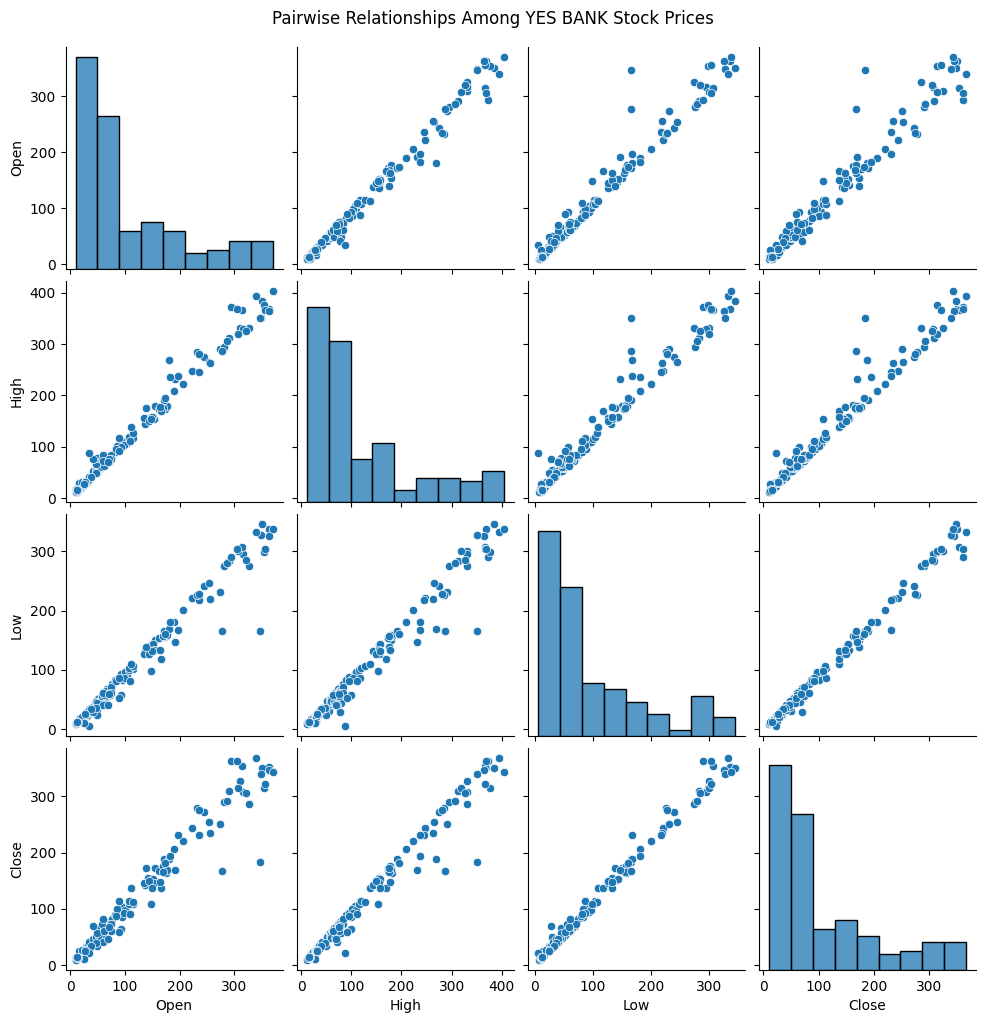

In [39]:
# Pair Plot visualization code
sns.pairplot(
    df[['Open', 'High', 'Low', 'Close']],
    diag_kind='hist'
)

plt.suptitle(
    'Pairwise Relationships Among YES BANK Stock Prices',
    y=1.02
)

plt.show()

##### 1. Why did you pick the specific chart?

I selected a **pair plot** to study the relationships between all major YES BANK stock price variables together. It shows the individual distributions and pairwise relationships between Open, High, Low, and Close prices in a single chart.


##### 2. What is/are the insight(s) found from the chart?

- There is a **strong positive relationship** between all four price variables.
- Open, High, Low, and Close prices generally **increase together**.
- The scatter plots show clear upward patterns with most points close to the main trend.
- The diagonal histograms show that most price observations are concentrated in the **lower price ranges**.
- Some observations appear away from the main pattern, indicating **unusual price movements**.
- The distributions are generally **right-skewed**, with fewer observations at higher price levels.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

`Research Question`

Is there a significant relationship between YES BANK's Opening Price and Closing Price?

Null Hypothesis `(H₀)`:
There is no significant relationship between YES BANK's Opening Price and Closing Price. The observed correlation is due to random chance.

Alternative Hypothesis `(H₁)`:
There is a significant relationship between YES BANK's Opening Price and Closing Price.

#### 2. Perform an appropriate statistical test.

In [40]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

# Perform Pearson Correlation Test
correlation, p_value = pearsonr(df['Open'], df['Close'])

h0 = "There is no significant relationship between YES BANK's Opening Price and Closing Price. The observed correlation is due to random chance."
hA = "There is a significant relationship between YES BANK's Opening Price and Closing Price."

print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.10f}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    verdict = hA
else:
    print("Fail to Reject H0")
    verdict = h0

print(verdict)

Pearson Correlation: 0.9780
P-value: 0.0000000000
Reject H0
There is a significant relationship between YES BANK's Opening Price and Closing Price.


##### Which statistical test have you done to obtain P-Value?

I used the Pearson Correlation Test to obtain the p-value.

##### Why did you choose the specific statistical test?

The Pearson correlation test is appropriate because both Opening Price and Closing Price are continuous numerical variables, and the scatter plot shows a strong linear relationship between them. The test helps determine whether this observed relationship is statistically significant.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

`Research Question`

Does the distribution of YES BANK Closing Prices differ across calendar months?


Null Hypothesis `(H₀)`:
The distribution of YES BANK Closing Prices is the same across all calendar months. Any observed differences are due to random chance.

Alternative Hypothesis `(H₁)`:
At least one calendar month has a different distribution of YES BANK Closing Prices compared with the other months.

#### 2. Perform an appropriate statistical test.

In [41]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import kruskal

# Create groups for each calendar month
groups = [
    df.loc[df['Month'] == month, 'Close']
    for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
]

# Perform Kruskal-Wallis Test
h_stat, p_value = kruskal(*groups)

h0 = "The distribution of YES BANK Closing Prices is the same across all calendar months. Any observed differences are due to random chance."
hA = "At least one calendar month has a different distribution of YES BANK Closing Prices compared with the other months."

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.10f}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    verdict = hA
else:
    print("Fail to Reject H0")
    verdict = h0

print(verdict)

H-statistic: 1.1962
P-value: 0.9998756524
Fail to Reject H0
The distribution of YES BANK Closing Prices is the same across all calendar months. Any observed differences are due to random chance.


##### Which statistical test have you done to obtain P-Value?

I used the Kruskal-Wallis H Test to obtain the p-value.

##### Why did you choose the specific statistical test?

The Kruskal-Wallis test is appropriate because we are comparing the Closing Prices across 12 independent calendar-month groups. It is a non-parametric test and does not require the data in each group to follow a normal distribution.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

`Research Question`

Does the distribution of YES BANK Closing Prices differ across different years?


Null Hypothesis `(H₀)`:
The distribution of YES BANK Closing Prices is the same across all years. Any observed differences are due to random chance.

Alternative Hypothesis `(H₁)`:
At least one year has a different distribution of YES BANK Closing Prices compared with the other years.

#### 2. Perform an appropriate statistical test.

In [42]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import kruskal

# Create groups for each year
groups = [
    df.loc[df['Year'] == year, 'Close']
    for year in sorted(df['Year'].unique())
]

# Perform Kruskal-Wallis Test
h_stat, p_value = kruskal(*groups)

h0 = "The distribution of YES BANK Closing Prices is the same across all years. Any observed differences are due to random chance."
hA = "At least one year has a different distribution of YES BANK Closing Prices compared with the other years."

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.10f}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    verdict = hA
else:
    print("Fail to Reject H0")
    verdict = h0

print(verdict)

H-statistic: 167.9933
P-value: 0.0000000000
Reject H0
At least one year has a different distribution of YES BANK Closing Prices compared with the other years.


##### Which statistical test have you done to obtain P-Value?

I used the Kruskal-Wallis H Test to obtain the p-value.

##### Why did you choose the specific statistical test?

The Kruskal-Wallis test is appropriate because we are comparing the Closing Prices across multiple independent year groups. It is a non-parametric test, so it does not require the Closing Prices in each year to follow a normal distribution.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [55]:
# check the missing values
df.isnull().sum()

Date               0
Open               0
High               0
Low                0
Close              0
Year               0
Month              0
Previous_Close     0
Previous_Open      0
Previous_High      0
Previous_Low       0
MA_3               0
MA_6               0
Previous_Return    0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing-value treatment was required because the dataset contains complete observations.

### 2. Handling Outliers

In [44]:
import pandas as pd

# Columns for outlier detection
price_columns = ['Open', 'High', 'Low', 'Close']

# Detect outliers using the IQR method
outlier_summary = {}

for col in price_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': len(outliers)
    }

# Display outlier summary
outlier_summary_df = pd.DataFrame(outlier_summary).T
outlier_summary_df

,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
Open,33.80,153.00,119.20,-145.000,331.800,9.0
High,36.14,169.19,133.05,-163.435,368.765,5.0
Low,28.51,138.35,109.84,-136.250,303.110,9.0
Close,33.45,153.30,119.85,-146.325,333.075,9.0


##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the **Interquartile Range (IQR) method** to detect potential outliers in the Open, High, Low, and Close price variables.

The IQR method was selected because it is suitable for numerical data and is less affected by extreme values compared with methods based on the mean and standard deviation.

The analysis identified some extreme price observations. However, these observations were **not removed or replaced**, because they represent actual historical movements in YES BANK's stock price.

Removing these observations could result in the loss of important information about periods of high price movement. Therefore, the outliers were retained after checking their relevance to the stock-price data.

This approach helps preserve the **original market behavior** while avoiding unnecessary modification of genuine observations.

### 3. Categorical Encoding

In [45]:
# Encode your categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=['Month'],
    drop_first=True,
    dtype=int
)

In [46]:
df_encoded.head()

,Date,Open,High,Low,Close,Year,Month_Aug,Month_Dec,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,2005-07-01,13.00,14.00,11.25,12.46,2005,0,0,0,0,1,0,0,0,0,0,0
1,2005-08-01,12.58,14.88,12.55,13.42,2005,1,0,0,0,0,0,0,0,0,0,0
2,2005-09-01,13.48,14.87,12.27,13.30,2005,0,0,0,0,0,0,0,0,0,0,1
3,2005-10-01,13.20,14.47,12.40,12.99,2005,0,0,0,0,0,0,0,0,0,1,0
4,2005-11-01,13.35,13.88,12.88,13.41,2005,0,0,0,0,0,0,0,0,1,0,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used **One-Hot Encoding** for the `Month` column because Month is a categorical variable. One-Hot Encoding converts each month into a separate binary feature without assigning an artificial numerical order to the months.

I used `drop_first=True` to avoid the dummy variable trap and reduce unnecessary redundancy among the encoded variables.

The encoded Month features can then be used by the regression model as numerical inputs.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [47]:
# Step 1: Create lag features

# Sort data according to date
df = df.sort_values('Date').reset_index(drop=True)

# Previous month's stock prices
df['Previous_Close'] = df['Close'].shift(1)
df['Previous_Open'] = df['Open'].shift(1)
df['Previous_High'] = df['High'].shift(1)
df['Previous_Low'] = df['Low'].shift(1)

df.head()

,Date,Open,High,Low,Close,Year,Month,Previous_Close,Previous_Open,Previous_High,Previous_Low
0,2005-07-01,13.00,14.00,11.25,12.46,2005,Jul,NaN,NaN,NaN,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,Aug,12.46,13.00,14.00,11.25
2,2005-09-01,13.48,14.87,12.27,13.30,2005,Sep,13.42,12.58,14.88,12.55
3,2005-10-01,13.20,14.47,12.40,12.99,2005,Oct,13.30,13.48,14.87,12.27
4,2005-11-01,13.35,13.88,12.88,13.41,2005,Nov,12.99,13.20,14.47,12.40


In [48]:
# Step 2: Create moving average features
# Moving averages based on previous closing prices
df['MA_3'] = df['Close'].shift(1).rolling(window=3).mean()
df['MA_6'] = df['Close'].shift(1).rolling(window=6).mean()
df.head()

,Date,Open,High,Low,Close,Year,Month,Previous_Close,Previous_Open,Previous_High,Previous_Low,MA_3,MA_6
0,2005-07-01,13.00,14.00,11.25,12.46,2005,Jul,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,Aug,12.46,13.00,14.00,11.25,NaN,NaN
2,2005-09-01,13.48,14.87,12.27,13.30,2005,Sep,13.42,12.58,14.88,12.55,NaN,NaN
3,2005-10-01,13.20,14.47,12.40,12.99,2005,Oct,13.30,13.48,14.87,12.27,13.060000,NaN
4,2005-11-01,13.35,13.88,12.88,13.41,2005,Nov,12.99,13.20,14.47,12.40,13.236667,NaN


In [49]:
# Step 3: Create previous month's return
# Previous month's percentage return
df['Previous_Return'] = df['Close'].shift(1).pct_change()

df.head()

,Date,Open,High,Low,Close,Year,Month,Previous_Close,Previous_Open,Previous_High,Previous_Low,MA_3,MA_6,Previous_Return
0,2005-07-01,13.00,14.00,11.25,12.46,2005,Jul,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,Aug,12.46,13.00,14.00,11.25,NaN,NaN,NaN
2,2005-09-01,13.48,14.87,12.27,13.30,2005,Sep,13.42,12.58,14.88,12.55,NaN,NaN,0.077047
3,2005-10-01,13.20,14.47,12.40,12.99,2005,Oct,13.30,13.48,14.87,12.27,13.060000,NaN,-0.008942
4,2005-11-01,13.35,13.88,12.88,13.41,2005,Nov,12.99,13.20,14.47,12.40,13.236667,NaN,-0.023308


In [50]:
# Step 4: Check the newly created features
df[['Date', 'Close', 'Previous_Close', 'Previous_Open',
    'Previous_High', 'Previous_Low', 'MA_3', 'MA_6',
    'Previous_Return']].head(10)

,Date,Close,Previous_Close,Previous_Open,Previous_High,Previous_Low,MA_3,MA_6,Previous_Return
0,2005-07-01,12.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-08-01,13.42,12.46,13.00,14.00,11.25,NaN,NaN,NaN
2,2005-09-01,13.30,13.42,12.58,14.88,12.55,NaN,NaN,0.077047
3,2005-10-01,12.99,13.30,13.48,14.87,12.27,13.060000,NaN,-0.008942
4,2005-11-01,13.41,12.99,13.20,14.47,12.40,13.236667,NaN,-0.023308
5,2005-12-01,13.71,13.41,13.35,13.88,12.88,13.233333,NaN,0.032333
6,2006-01-01,15.33,13.71,13.49,14.44,13.00,13.370000,13.215000,0.022371
7,2006-02-01,16.12,15.33,13.68,17.16,13.58,14.150000,13.693333,0.118162
8,2006-03-01,20.08,16.12,15.50,16.97,15.40,15.053333,14.143333,0.051533
9,2006-04-01,19.49,20.08,16.20,20.95,16.02,17.176667,15.273333,0.245658


In [51]:
# Step 5: Remove rows created with missing values
df = df.dropna().reset_index(drop=True)

df.head()

,Date,Open,High,Low,Close,Year,Month,Previous_Close,Previous_Open,Previous_High,Previous_Low,MA_3,MA_6,Previous_Return
0,2006-01-01,13.68,17.16,13.58,15.33,2006,Jan,13.71,13.49,14.44,13.00,13.370000,13.215000,0.022371
1,2006-02-01,15.50,16.97,15.40,16.12,2006,Feb,15.33,13.68,17.16,13.58,14.150000,13.693333,0.118162
2,2006-03-01,16.20,20.95,16.02,20.08,2006,Mar,16.12,15.50,16.97,15.40,15.053333,14.143333,0.051533
3,2006-04-01,20.56,20.80,18.02,19.49,2006,Apr,20.08,16.20,20.95,16.02,17.176667,15.273333,0.245658
4,2006-05-01,19.80,21.80,15.80,18.03,2006,May,19.49,20.56,20.80,18.02,18.563333,16.356667,-0.029382


Feature manipulation was performed to create new meaningful features from the existing YES BANK stock-price data.

Since the dataset is a time-series dataset, **lag features** were created using the previous month's Open, High, Low, and Close prices. These features provide historical information that can be used to predict the current month's Closing Price.

Two moving average features, **MA_3 and MA_6**, were created using the previous 3-month and 6-month closing prices. These features help capture the recent price trend.

The **Previous_Return** feature was also created to represent the percentage change in the previous month's closing price.

The first few rows containing missing values due to lag and rolling calculations were removed because sufficient historical information was not available for those observations.

In [52]:
df.to_csv(r"clean_dataset/data_for_ml_model.csv",index=False)

#### 2. Feature Selection

In [56]:
# Step 1: Check correlation with the target
# Select numerical features
features = [
    'Previous_Close',
    'Previous_Open',
    'Previous_High',
    'Previous_Low',
    'MA_3',
    'MA_6',
    'Previous_Return',
    'Year'
]

# Correlation of features with the target variable
correlation_with_close = (
    df[features + ['Close']]
    .corr()['Close']
    .sort_values(ascending=False)
)

print(correlation_with_close)

Close              1.000000
Previous_Close     0.977665
Previous_Low       0.972393
MA_3               0.964295
Previous_High      0.957506
Previous_Open      0.952875
MA_6               0.944887
Year               0.592984
Previous_Return    0.060951
Name: Close, dtype: float64


In [57]:
# Step 2: Visualize the correlations
import plotly.express as px

corr_data = (
    df[features + ['Close']]
    .corr()['Close']
    .drop('Close')
    .reset_index()
)

corr_data.columns = ['Feature', 'Correlation']

fig = px.bar(
    corr_data,
    x='Feature',
    y='Correlation',
    title='Correlation of Features with YES BANK Closing Price',
    labels={
        'Feature': 'Feature',
        'Correlation': 'Correlation with Close'
    }
)

fig.show()

In [58]:
import numpy as np
import pandas as pd

# Select features
X_vif = df[features].copy()

# Calculate VIF manually
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns

vif_data['VIF'] = [
    1 / (1 - np.linalg.inv(X_vif.corr().values).diagonal()[i])
    for i in range(X_vif.shape[1])
]

vif_data.sort_values('VIF', ascending=False)

,Feature,VIF
4,MA_3,-0.002479
0,Previous_Close,-0.004011
3,Previous_Low,-0.004620
1,Previous_Open,-0.005063
2,Previous_High,-0.005547
5,MA_6,-0.015145
7,Year,-0.978168
6,Previous_Return,-1.089469


In [59]:
import numpy as np
import pandas as pd

# Select features
X_vif = df[features].copy()

vif_data = []

for i, feature in enumerate(X_vif.columns):
    
    X_other = X_vif.drop(columns=[feature])
    y_feature = X_vif[feature]
    
    # Add constant
    X_other = np.column_stack([
        np.ones(len(X_other)),
        X_other.values
    ])
    
    # Calculate coefficients using least squares
    coefficients = np.linalg.lstsq(
        X_other,
        y_feature.values,
        rcond=None
    )[0]
    
    # Predicted values
    y_pred = X_other @ coefficients
    
    # R-squared
    ss_res = np.sum((y_feature.values - y_pred) ** 2)
    ss_tot = np.sum((y_feature.values - y_feature.mean()) ** 2)
    
    r_squared = 1 - (ss_res / ss_tot)
    
    # VIF
    vif = 1 / (1 - r_squared)
    
    vif_data.append([feature, vif])

vif_data = pd.DataFrame(
    vif_data,
    columns=['Feature', 'VIF']
)

vif_data.sort_values('VIF', ascending=False)

,Feature,VIF
4,MA_3,404.353712
0,Previous_Close,250.306444
3,Previous_Low,217.454208
1,Previous_Open,198.529188
2,Previous_High,181.274098
5,MA_6,67.029279
7,Year,2.022319
6,Previous_Return,1.917878


In [60]:
# Step 4: Select the final features

# For the initial regression model,

selected_features = [
    'Previous_Close',
    'MA_3',
    'MA_6',
    'Previous_Return',
    'Year'
]

# X = df[selected_features]
# y = df['Close']

# print("Selected Features:")
# print(selected_features)

# print("\nTarget Variable:")
# print(y.name)

##### What all feature selection methods have you used  and why?

I used **Correlation Analysis** and **Variance Inflation Factor (VIF) Analysis** for feature selection.

**1. Correlation Analysis:**  
Correlation analysis was used to understand the relationship between each feature and the target variable, `Close`. It helped identify features that have a strong relationship with the Closing Price.

For example, `Previous_Close` showed a very strong positive correlation of **0.9777** with the target variable.

**2. Variance Inflation Factor (VIF):**  
VIF analysis was used to identify **multicollinearity among the predictor variables**. This was important because several engineered features were created from related stock-price information.

The VIF analysis showed very high multicollinearity among features such as `MA_3`, `Previous_Close`, `Previous_Low`, `Previous_Open`, `Previous_High`, and `MA_6`. Therefore, VIF was used to identify features that contain highly overlapping information.

These methods were selected because correlation helps understand the relationship with the target, while VIF helps identify redundancy among the predictor variables. Together, they provide a better basis for selecting features for the regression model.

##### Which all features you found important and why?

Based on the correlation analysis and VIF analysis, the following features were considered important for predicting YES BANK's Closing Price:

- **Previous_Close:** It was considered an important feature because it showed the strongest positive correlation with the target variable `Close`, with a correlation of **0.9777**. This indicates that the previous month's Closing Price has a strong relationship with the current Closing Price.

- **Year:** It was considered important because it showed a moderate positive correlation of **0.5930** with the target variable. It also had a VIF of **2.02**, indicating that it does not have a serious multicollinearity problem.

- **Previous_Return:** Although it showed a weak correlation of **0.0610** with the Closing Price, it had a low VIF of **1.92**. It represents the previous month's percentage price movement and provides different information from the absolute price features.

Features such as **Previous_Open, Previous_High, Previous_Low, MA_3, and MA_6** also showed strong relationships with the Closing Price. However, their very high VIF values indicated substantial multicollinearity with other predictor variables. Therefore, their final inclusion should be determined by comparing model performance rather than relying only on correlation.

Overall, **Previous_Close, Year, and Previous_Return** were identified as the initial important features because they provide useful information while having comparatively lower multicollinearity.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation is required for the numerical features used in the regression model.

I used **Standardization (Z-score scaling)** using `StandardScaler`. This transformation converts the features to a common scale by centering them around a mean of 0 and scaling them to have a standard deviation of approximately 1.

Standardization was selected because the features have different numerical scales. For example, `Year` contains values around 2005–2020, while `Previous_Return` contains much smaller decimal values and `Previous_Close` contains stock-price values.

Scaling the features helps prevent variables with larger numerical values from having an unnecessary influence on scale-sensitive regression algorithms. It is particularly useful for models such as Linear Regression with regularization, Ridge Regression, and Lasso Regression.

The target variable `Close` was not standardized at this stage because the model needs to predict the Closing Price in its original units.

In [61]:
# Transform Your data
from sklearn.preprocessing import StandardScaler

# Select the features for transformation
selected_features = [
    'Previous_Close',
    'Previous_Return',
    'Year'
]

X = df[selected_features].copy()

# Apply Standardization
scaler = StandardScaler()

X_transformed = scaler.fit_transform(X)

# Convert transformed data back to DataFrame
X_transformed = pd.DataFrame(
    X_transformed,
    columns=selected_features,
    index=X.index
)

X_transformed.head()

,Previous_Close,Previous_Return,Year
0,-0.960342,0.050575,-1.618564
1,-0.943892,0.625511,-1.618564
2,-0.935870,0.225603,-1.618564
3,-0.895658,1.390740,-1.618564
4,-0.901649,-0.260051,-1.618564


In [62]:
print("Mean:")
print(X_transformed.mean())

print("\nStandard Deviation:")
print(X_transformed.std())

Mean:
Previous_Close     1.190854e-16
Previous_Return    0.000000e+00
Year               1.960939e-14
dtype: float64

Standard Deviation:
Previous_Close     1.002805
Previous_Return    1.002805
Year               1.002805
dtype: float64


### 6. Data Scaling

In [63]:
from sklearn.preprocessing import StandardScaler

# Define features and target
selected_features = [
    'Previous_Close',
    'Previous_Return',
    'Year'
]

X = df[selected_features]
y = df['Close']

# Time-based train-test split (80% training, 20% testing)
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=selected_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=selected_features,
    index=X_test.index
)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (143, 3)
Testing data shape: (36, 3)


In [64]:
df[selected_features].head()

,Previous_Close,Previous_Return,Year
0,13.71,0.022371,2006
1,15.33,0.118162,2006
2,16.12,0.051533,2006
3,20.08,0.245658,2006
4,19.49,-0.029382,2006


##### Which method have you used to scale you data and why?

We used **Standardization (Z-score Scaling)** using `StandardScaler`.

Standardization was selected because the features have different numerical ranges. It transforms the features to a common scale with a mean close to 0 and a standard deviation close to 1.

This scaling method is suitable for regression algorithms such as Linear Regression, Ridge, and Lasso, where feature scale can influence the model.

The scaler was fitted only on the training data and then applied to the testing data to avoid data leakage.

In [65]:
df[selected_features].to_csv(r"clean_dataset/selected_feature_for_ml_model.csv",index=False)

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [66]:
# Split your data to train and test. Choose Splitting ratio wisely.
# Define features and target
selected_features = [
    'Previous_Close',
    'Previous_Return',
    'Year'
]

X = df[selected_features]
y = df['Close']

# 80% Training and 20% Testing
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (143, 3)
Testing data shape: (36, 3)


##### What data splitting ratio have you used and why? 

An **80:20 train-test split** was used, where 80% of the observations were used for training and 20% were reserved for testing.

The 80:20 ratio provides sufficient historical data for the model to learn while retaining enough unseen observations to evaluate its predictive performance.

Because this is time-series stock-price data, the split was performed chronologically. The earlier observations were used for training, and the later observations were used for testing to maintain the natural time order and avoid using future information during training.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the dataset is not considered imbalanced.

This project is a **regression problem**, where the target variable `Close` is a continuous numerical variable. Unlike classification problems, there are no predefined classes whose proportions need to be balanced.

Therefore, techniques such as SMOTE, oversampling, undersampling, or class weighting are not required. The dataset can be used for regression modeling without applying traditional class-imbalance handling techniques.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1 Linear Regression

In [38]:
# ML Model - 1 Implementation

from sklearn.linear_model import LinearRegression

# Create Linear Regression model
lr_model = LinearRegression()

# Fit the algorithm on training data
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model fitted successfully.")



# Predict on the test data
y_pred_lr = lr_model.predict(X_test_scaled)

# Display first 10 predictions
prediction_df = pd.DataFrame({
    'Actual_Close': y_test.values,
    'Predicted_Close': y_pred_lr
})

print(prediction_df.head(10))

Linear Regression model fitted successfully.
   Actual_Close  Predicted_Close
0        315.05       307.610638
1        354.45       317.223999
2        322.25       355.952929
3        304.90       323.226524
4        362.05       306.807663
5        346.20       363.767647
6        339.60       346.668724
7        367.90       340.507206
8        343.40       368.577794
9        183.45       343.790933


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print evaluation metrics
print("Linear Regression - Evaluation Metrics")
print("---------------------------------------")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression - Evaluation Metrics
---------------------------------------
MAE  : 28.7027
MSE  : 1685.8930
RMSE : 41.0596
R²   : 0.8962


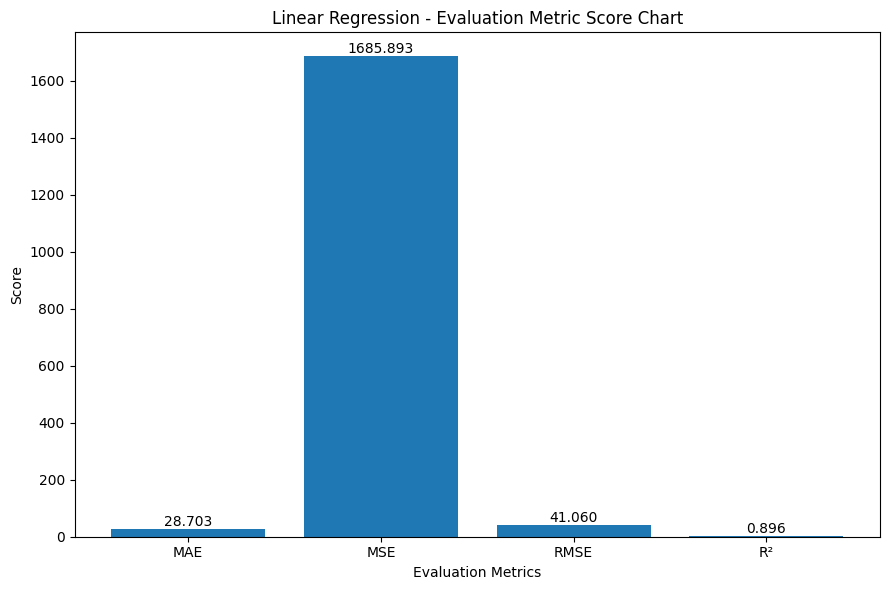

In [40]:
# Visualizing evaluation Metric Score chart
# Visualizing Evaluation Metric Score Chart

metrics = ['MAE', 'MSE', 'RMSE', 'R²']
scores = [mae_lr, mse_lr, rmse_lr, r2_lr]

plt.figure(figsize=(9, 6))

bars = plt.bar(metrics, scores)

plt.title("Linear Regression - Evaluation Metric Score Chart")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

# Display values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

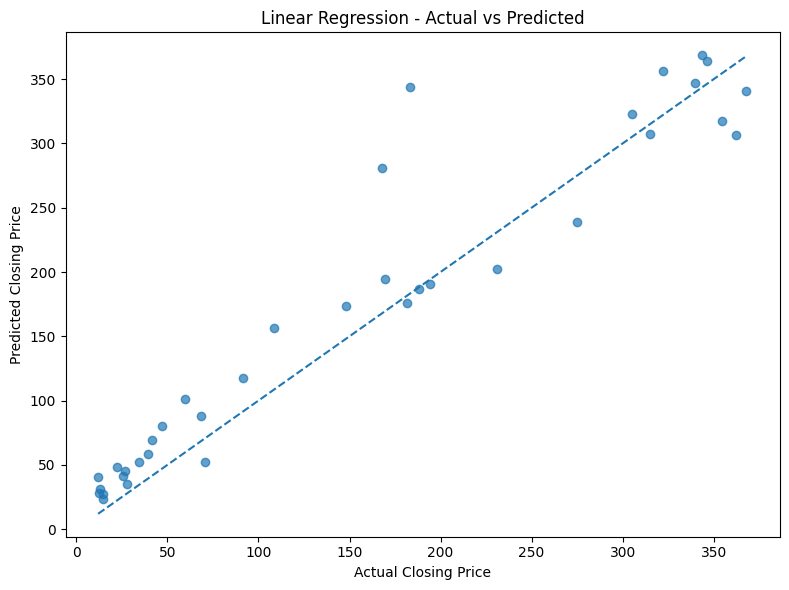

In [41]:
#Actual vs Predicted Chart
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_lr.min())
max_value = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title("Linear Regression - Actual vs Predicted")
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")

plt.tight_layout()
plt.show()

**Linear Regression** was used as the first machine learning model because it is a simple and interpretable regression algorithm suitable for predicting the continuous `Close` price.

The model was trained using the training dataset and evaluated on the unseen testing dataset.

The following evaluation metrics were used:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted closing prices. Lower values indicate better performance.
- **MSE (Mean Squared Error):** Measures the average squared prediction error and gives greater importance to larger errors. Lower values indicate better performance.
- **RMSE (Root Mean Squared Error):** Measures the prediction error in approximately the same unit as the closing price. Lower values indicate better performance.
- **R² Score:** Measures how much variation in the closing price is explained by the model. Higher values indicate better performance.

The Actual vs Predicted chart was also used to visually compare the predicted closing prices with the actual closing prices.

#### 2. Cross- Validation & Hyperparameter Tuning

cross validation 

In [42]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# Define Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

# Perform cross-validation
cv_scores_lr = cross_validate(
    lr_model,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'r2'
    ],
    n_jobs=-1
)

# Convert negative error scores to positive values
cv_mae_lr = -cv_scores_lr['test_neg_mean_absolute_error']
cv_mse_lr = -cv_scores_lr['test_neg_mean_squared_error']
cv_rmse_lr = -cv_scores_lr['test_neg_root_mean_squared_error']
cv_r2_lr = cv_scores_lr['test_r2']

print("Linear Regression - Cross Validation")
print("-------------------------------------")
print(f"Mean MAE  : {cv_mae_lr.mean():.4f}")
print(f"Mean MSE  : {cv_mse_lr.mean():.4f}")
print(f"Mean RMSE : {cv_rmse_lr.mean():.4f}")
print(f"Mean R²   : {cv_r2_lr.mean():.4f}")

Linear Regression - Cross Validation
-------------------------------------
Mean MAE  : 10.1601
Mean MSE  : 224.8226
Mean RMSE : 12.8383
Mean R²   : 0.5248


hyper tuning

In [43]:
# Linear Regression itself has no important regularization hyperparameter to tune. 
# Therefore, for a meaningful hyperparameter-optimization step, 
# we can use Ridge Regression as the tuned version of the linear model.

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Create Ridge Regression model
ridge_model = Ridge()

# Define hyperparameter grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# Grid Search with TimeSeriesSplit
grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit Grid Search
grid_search.fit(X_train_scaled, y_train)

print("Best Hyperparameter:")
print(grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search.best_score_)

Best Hyperparameter:
{'alpha': 0.01}

Best Cross-Validation RMSE:
12.543052759674818


In [44]:
# Get the best Ridge model
best_ridge_model = grid_search.best_estimator_

# Predict on test data
y_pred_ridge = best_ridge_model.predict(X_test_scaled)

# Calculate evaluation metrics
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Tuned Ridge Regression - Test Performance")
print("------------------------------------------")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

Tuned Ridge Regression - Test Performance
------------------------------------------
MAE  : 28.7220
MSE  : 1686.5468
RMSE : 41.0676
R²   : 0.8961


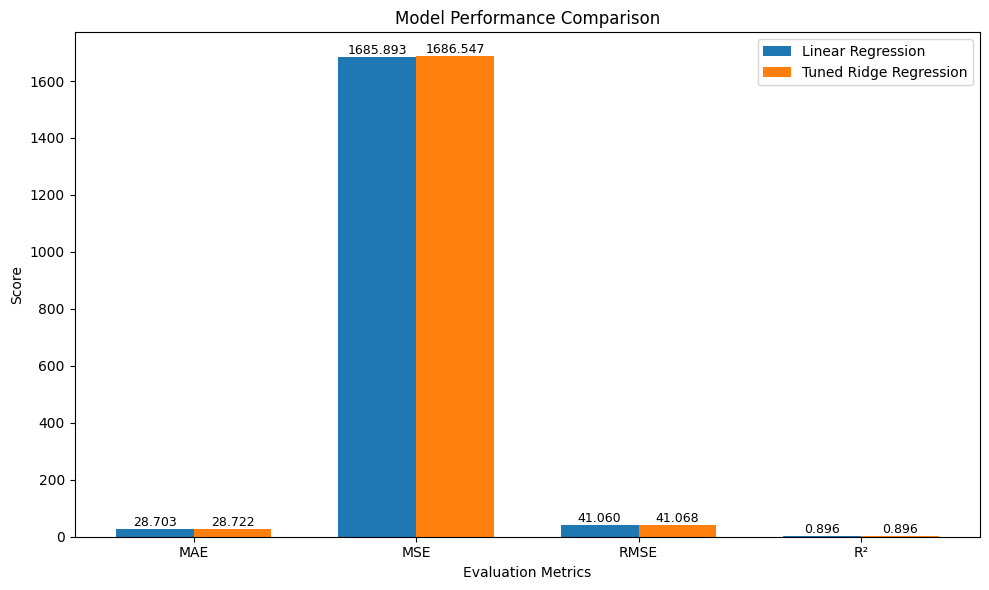

In [45]:
# Compare Linear Regression and Tuned Ridge Regression

metrics = ['MAE', 'MSE', 'RMSE', 'R²']

linear_scores = [
    mae_lr,
    mse_lr,
    rmse_lr,
    r2_lr
]

ridge_scores = [
    mae_ridge,
    mse_ridge,
    rmse_ridge,
    r2_ridge
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    linear_scores,
    width,
    label='Linear Regression'
)

bars2 = plt.bar(
    x + width / 2,
    ridge_scores,
    width,
    label='Tuned Ridge Regression'
)

plt.xticks(x, metrics)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

# Add values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** was used for hyperparameter optimization.

GridSearchCV systematically tests different combinations of hyperparameter values and selects the combination that provides the best cross-validation performance.

For Ridge Regression, the `alpha` hyperparameter was tuned using the values:

`0.01, 0.1, 1, 10, 100`

**TimeSeriesSplit** was used for cross-validation because the dataset contains time-dependent stock-price observations. It maintains the chronological order of the data and prevents future observations from being used to train the model.

Therefore, GridSearchCV combined with TimeSeriesSplit was used to identify the most suitable `alpha` value while maintaining the time-series nature of the dataset.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No significant improvement was observed after hyperparameter tuning of the Ridge Regression model.

The performance of the baseline Linear Regression and tuned Ridge Regression models was very similar.

- **MAE:** increased slightly from `28.703` to `28.722`.
- **MSE:** increased slightly from `1685.893` to `1686.547`.
- **RMSE:** increased slightly from `41.060` to `41.068`.
- **R² Score:** remained approximately the same at `0.896`.

Therefore, hyperparameter tuning with Ridge Regression did not improve the model's performance on the test dataset. The updated Evaluation Metric Score Chart also shows that both models have almost identical performance.

This indicates that, for the current feature set, Ridge regularization did not provide a meaningful performance advantage over the baseline Linear Regression model.

### ML Model - 2 Random Forest Regression

In [107]:
# ML Model - 2 Implementation

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest Regressor
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Fit the algorithm
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model fitted successfully.")


# Predict on the test data
y_pred_rf = rf_model.predict(X_test)

# Display first 10 predictions
prediction_df_rf = pd.DataFrame({
    'Actual_Close': y_test.values,
    'Predicted_Close': y_pred_rf
})

print(prediction_df_rf.head(10))

Random Forest Regressor model fitted successfully.
   Actual_Close  Predicted_Close
0        315.05         323.0048
1        354.45         325.7311
2        322.25         330.4460
3        304.90         306.1064
4        362.05         318.4142
5        346.20         335.2222
6        339.60         322.0549
7        367.90         322.5591
8        343.40         332.8146
9        183.45         316.2350


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [108]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Print evaluation metrics
print("Random Forest Regression - Evaluation Metrics")
print("----------------------------------------------")
print(f"MAE  : {mae_rf:.4f}")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Regression - Evaluation Metrics
----------------------------------------------
MAE  : 27.9482
MSE  : 1515.6818
RMSE : 38.9318
R²   : 0.9067


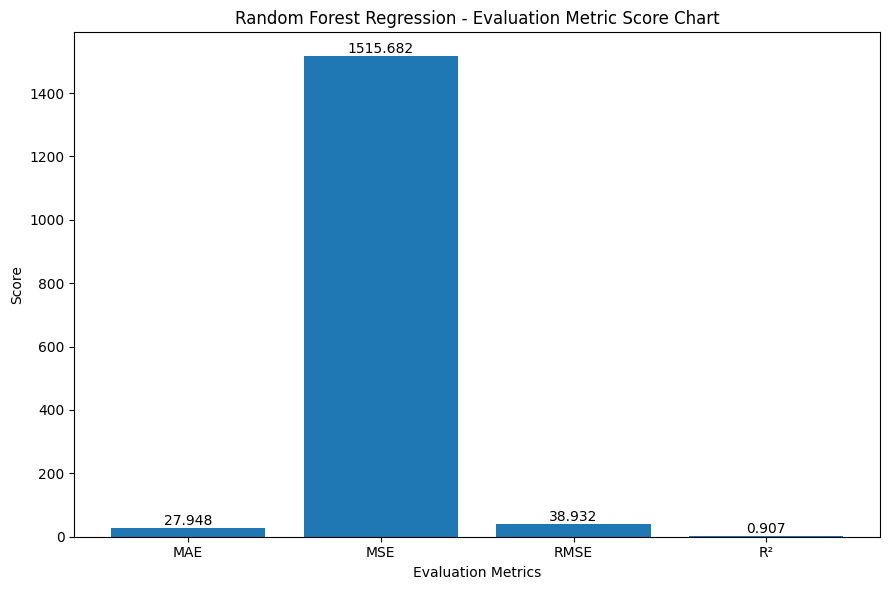

In [109]:
# Visualizing Evaluation Metric Score Chart

metrics = ['MAE', 'MSE', 'RMSE', 'R²']
scores = [mae_rf, mse_rf, rmse_rf, r2_rf]

plt.figure(figsize=(9, 6))

bars = plt.bar(metrics, scores)

plt.title("Random Forest Regression - Evaluation Metric Score Chart")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

# Display values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

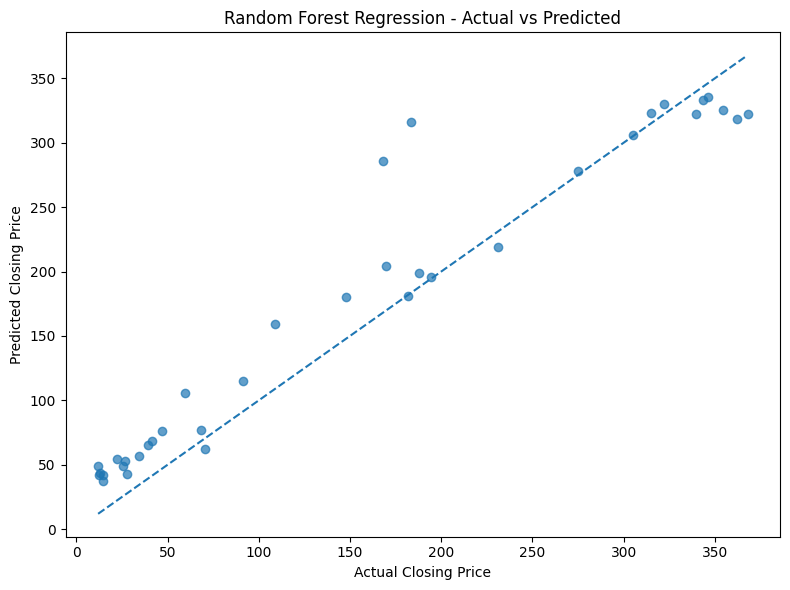

In [110]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title("Random Forest Regression - Actual vs Predicted")
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")

plt.tight_layout()
plt.show()

**Random Forest Regressor** was used as the second machine learning model.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to make predictions. Unlike Linear Regression, it can capture **non-linear relationships** between the input features and the target variable.

The model was evaluated using **MAE, MSE, RMSE, and R² Score**.

- **MAE:** Measures the average absolute prediction error. Lower values indicate better performance.
- **MSE:** Measures the average squared prediction error. Lower values indicate better performance.
- **RMSE:** Measures prediction error in approximately the same unit as the closing price. Lower values indicate better performance.
- **R² Score:** Measures the proportion of variation in the closing price explained by the model. Higher values indicate better performance.

The Actual vs Predicted chart was also used to visually compare the predicted closing prices with the actual closing prices.

#### 2. Cross- Validation & Hyperparameter Tuning

In [111]:
# For Random Forest, there are several meaningful hyperparameters, so GridSearchCV is appropriate.
# We'll continue using TimeSeriesSplit because this is stock-price time-series data.

from sklearn.model_selection import TimeSeriesSplit, cross_validate

# Define Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

# Cross-validation for Random Forest
cv_scores_rf = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=tscv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'r2'
    ],
    n_jobs=-1
)

# Convert negative error scores to positive
cv_mae_rf = -cv_scores_rf['test_neg_mean_absolute_error']
cv_mse_rf = -cv_scores_rf['test_neg_mean_squared_error']
cv_rmse_rf = -cv_scores_rf['test_neg_root_mean_squared_error']
cv_r2_rf = cv_scores_rf['test_r2']

print("Random Forest - Cross Validation")
print("---------------------------------")
print(f"Mean MAE  : {cv_mae_rf.mean():.4f}")
print(f"Mean MSE  : {cv_mse_rf.mean():.4f}")
print(f"Mean RMSE : {cv_rmse_rf.mean():.4f}")
print(f"Mean R²   : {cv_r2_rf.mean():.4f}")

Random Forest - Cross Validation
---------------------------------
Mean MAE  : 35.1731
Mean MSE  : 3260.3853
Mean RMSE : 40.9419
Mean R²   : -1.4712


hyperparameter tuning

In [112]:
from sklearn.model_selection import GridSearchCV

# Create Random Forest model for tuning
rf_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Define hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search with TimeSeriesSplit
grid_search_rf = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit Grid Search
grid_search_rf.fit(X_train, y_train)

print("Best Hyperparameters:")
print(grid_search_rf.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search_rf.best_score_)

Best Hyperparameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation RMSE:
40.61010924230574


Predict Using Tuned Random Forest

In [113]:
# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Predict on test data
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Calculate evaluation metrics
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest - Test Performance")
print("---------------------------------------")
print(f"MAE  : {mae_rf_tuned:.4f}")
print(f"MSE  : {mse_rf_tuned:.4f}")
print(f"RMSE : {rmse_rf_tuned:.4f}")
print(f"R²   : {r2_rf_tuned:.4f}")

Tuned Random Forest - Test Performance
---------------------------------------
MAE  : 27.4521
MSE  : 1513.8047
RMSE : 38.9076
R²   : 0.9068


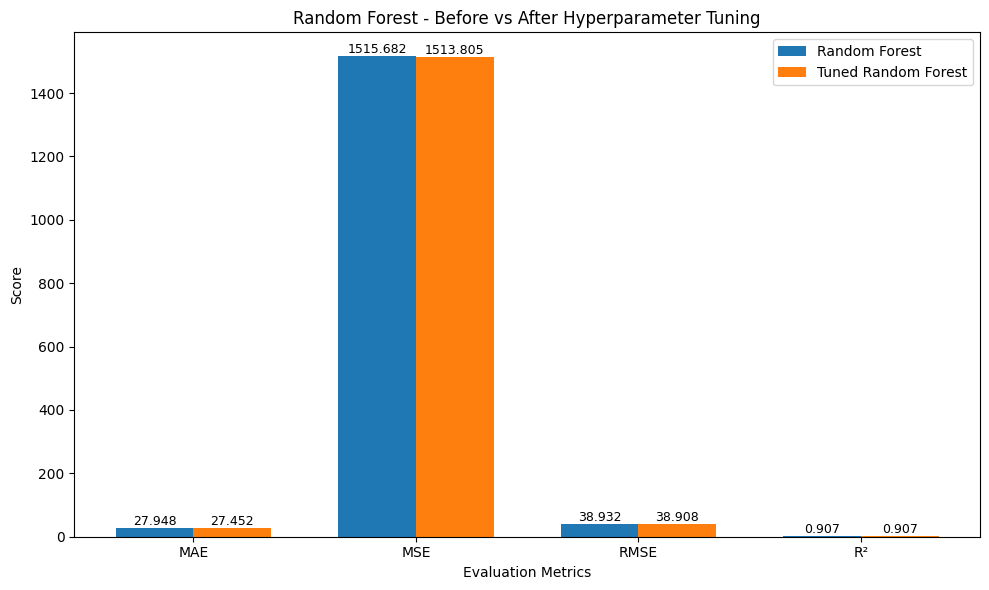

In [114]:
# Compare Random Forest before and after hyperparameter tuning

metrics = ['MAE', 'MSE', 'RMSE', 'R²']

rf_scores = [
    mae_rf,
    mse_rf,
    rmse_rf,
    r2_rf
]

rf_tuned_scores = [
    mae_rf_tuned,
    mse_rf_tuned,
    rmse_rf_tuned,
    r2_rf_tuned
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    rf_scores,
    width,
    label='Random Forest'
)

bars2 = plt.bar(
    x + width / 2,
    rf_tuned_scores,
    width,
    label='Tuned Random Forest'
)

plt.xticks(x, metrics)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Random Forest - Before vs After Hyperparameter Tuning")
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** was used for hyperparameter optimization.

GridSearchCV systematically evaluates different combinations of Random Forest hyperparameters and selects the combination that provides the best cross-validation performance.

The following hyperparameters were tuned:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

**TimeSeriesSplit** was used for cross-validation because the dataset contains time-dependent stock-price observations. It maintains the chronological order of the data and helps prevent future observations from being used during training.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, a **small improvement** was observed after hyperparameter tuning.

The tuned Random Forest model was compared with the baseline Random Forest model using MAE, MSE, RMSE, and R² Score.

- **MAE:** improved from `27.948` to `27.452`.
- **MSE:** improved from `1515.682` to `1513.805`.
- **RMSE:** improved from `38.932` to `38.908`.
- **R² Score:** remained the same at `0.907`.

The reduction in MAE, MSE, and RMSE indicates a small reduction in prediction error after hyperparameter tuning. However, the R² Score remained unchanged, indicating that the overall explanatory power of the model did not change significantly.

Therefore, hyperparameter tuning provided a **minor improvement in prediction error**, while the overall model performance remained very similar.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**1. Mean Absolute Error (MAE)**

MAE represents the average absolute difference between the actual and predicted closing prices.

**Business indication:**  
MAE directly indicates the average prediction error in the same unit as the stock price. A lower MAE means that the model's predictions are, on average, closer to the actual closing price.

**Business impact:**  
A lower MAE can help investors and financial analysts obtain more accurate estimates of expected closing prices. This can support better planning and reduce the uncertainty associated with price estimation.

---

**2. Mean Squared Error (MSE)**

MSE calculates the average squared difference between actual and predicted closing prices. Because the errors are squared, larger prediction errors have a greater impact on the metric.

**Business indication:**  
MSE helps identify whether the model is producing large prediction errors. A lower MSE indicates fewer or smaller large errors.

**Business impact:**  
Reducing large prediction errors is important in financial applications because significant deviations between predicted and actual prices can lead to incorrect financial analysis or decisions.

---

**3. Root Mean Squared Error (RMSE)**

RMSE is the square root of MSE and expresses the prediction error approximately in the same unit as the stock's closing price.

**Business indication:**  
RMSE indicates the typical magnitude of prediction error while giving greater importance to larger errors. A lower RMSE represents better predictive accuracy.

**Business impact:**  
A lower RMSE can provide more reliable price estimates and help analysts understand the level of uncertainty associated with the model's predictions.

---

**4. R² Score**

R² Score indicates the proportion of variation in the closing price that is explained by the model.

**Business indication:**  
A higher R² indicates that the model explains a larger proportion of the observed variation in the stock's closing price.

**Business impact:**  
A higher R² can indicate that the selected features capture meaningful patterns in historical stock prices, which can make the model more useful as an analytical forecasting tool.

---

##### Overall Business Impact of the ML Model

The Random Forest model achieved a test **MAE of 27.452, RMSE of 38.908, and R² of 0.907** in the current experiment.

The model can be used as a **supporting analytical tool** to estimate stock closing prices from historical features. It may help analysts identify price patterns, compare expected and actual prices, and support further financial analysis.

However, stock prices are affected by many external factors such as market conditions, economic events, company announcements, and investor sentiment. Therefore, the model's predictions should not be treated as guaranteed future prices or as a standalone basis for financial decisions.

### ML Model - 3  Decision Tree Regressor

In [99]:
# Since Decision Tree is a tree-based model, 
# we will use the original X_train and X_test, not the scaled versions.


# Fit the Algorithm
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree Regressor
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Fit the algorithm
dt_model.fit(X_train, y_train)

print("Decision Tree Regressor model fitted successfully.")

# Predict on the test data
y_pred_dt = dt_model.predict(X_test)

# Display first 10 predictions
prediction_df_dt = pd.DataFrame({
    'Actual_Close': y_test.values,
    'Predicted_Close': y_pred_dt
})

print(prediction_df_dt.head(10))

Decision Tree Regressor model fitted successfully.
   Actual_Close  Predicted_Close
0        315.05           361.96
1        354.45           286.38
2        322.25           350.00
3        304.90           306.80
4        362.05           361.96
5        346.20           351.15
6        339.60           314.35
7        367.90           314.35
8        343.40           351.15
9        183.45           314.35


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [100]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Print evaluation metrics
print("Decision Tree Regression - Evaluation Metrics")
print("-----------------------------------------------")
print(f"MAE  : {mae_dt:.4f}")
print(f"MSE  : {mse_dt:.4f}")
print(f"RMSE : {rmse_dt:.4f}")
print(f"R²   : {r2_dt:.4f}")

Decision Tree Regression - Evaluation Metrics
-----------------------------------------------
MAE  : 38.5467
MSE  : 2364.6449
RMSE : 48.6276
R²   : 0.8544


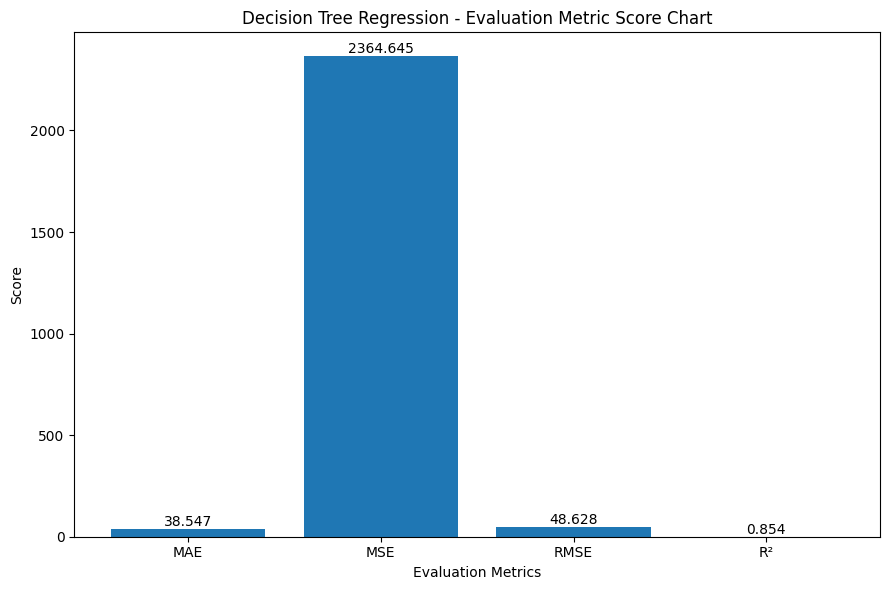

In [69]:
# Visualizing Evaluation Metric Score Chart

metrics = ['MAE', 'MSE', 'RMSE', 'R²']
scores = [mae_dt, mse_dt, rmse_dt, r2_dt]

plt.figure(figsize=(9, 6))

bars = plt.bar(metrics, scores)

plt.title("Decision Tree Regression - Evaluation Metric Score Chart")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

# Display values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

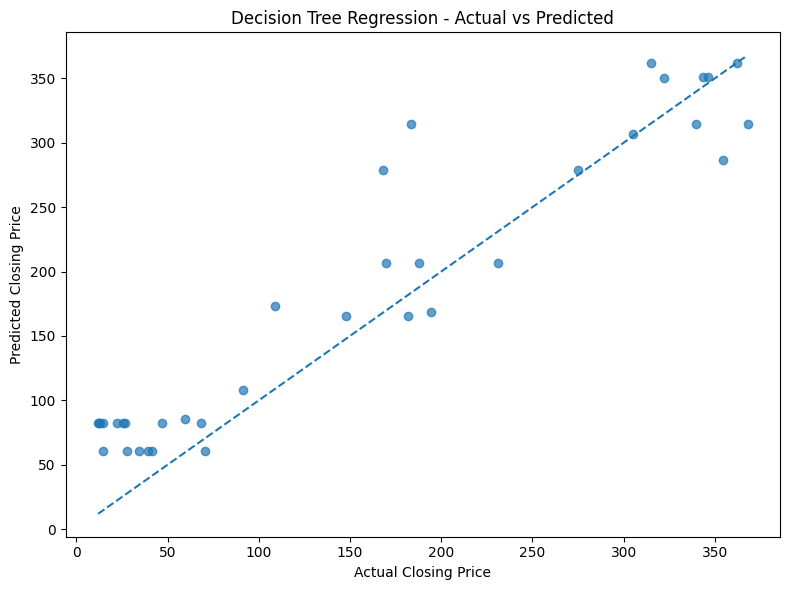

In [101]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_dt,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_dt.min())
max_value = max(y_test.max(), y_pred_dt.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title("Decision Tree Regression - Actual vs Predicted")
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")

plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

cross validation

In [102]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# Define Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

# Perform cross-validation
cv_scores_dt = cross_validate(
    dt_model,
    X_train,
    y_train,
    cv=tscv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'r2'
    ],
    n_jobs=-1
)

# Convert negative error scores to positive
cv_mae_dt = -cv_scores_dt['test_neg_mean_absolute_error']
cv_mse_dt = -cv_scores_dt['test_neg_mean_squared_error']
cv_rmse_dt = -cv_scores_dt['test_neg_root_mean_squared_error']
cv_r2_dt = cv_scores_dt['test_r2']

print("Decision Tree - Cross Validation")
print("---------------------------------")
print(f"Mean MAE  : {cv_mae_dt.mean():.4f}")
print(f"Mean MSE  : {cv_mse_dt.mean():.4f}")
print(f"Mean RMSE : {cv_rmse_dt.mean():.4f}")
print(f"Mean R²   : {cv_r2_dt.mean():.4f}")

Decision Tree - Cross Validation
---------------------------------
Mean MAE  : 34.7283
Mean MSE  : 3151.4650
Mean RMSE : 40.5381
Mean R²   : -1.4258


Hyperparameter Tuning

In [105]:
from sklearn.model_selection import GridSearchCV

# Create Decision Tree model for tuning
dt_tuning = DecisionTreeRegressor(
    random_state=42
)

# Define hyperparameter grid
param_grid_dt = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search with TimeSeriesSplit
grid_search_dt = GridSearchCV(
    estimator=dt_tuning,
    param_grid=param_grid_dt,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit Grid Search
grid_search_dt.fit(X_train, y_train)

print("Best Hyperparameters:")
print(grid_search_dt.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search_dt.best_score_)

Best Hyperparameters:
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Cross-Validation RMSE:
40.06678654559649


Predict Using Tuned Decision Tree

In [106]:
# Get the best Decision Tree model
best_dt_model = grid_search_dt.best_estimator_

# Predict on test data
y_pred_dt_tuned = best_dt_model.predict(X_test)

# Calculate evaluation metrics
mae_dt_tuned = mean_absolute_error(y_test, y_pred_dt_tuned)
mse_dt_tuned = mean_squared_error(y_test, y_pred_dt_tuned)
rmse_dt_tuned = np.sqrt(mse_dt_tuned)
r2_dt_tuned = r2_score(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree - Test Performance")
print("---------------------------------------")
print(f"MAE  : {mae_dt_tuned:.4f}")
print(f"MSE  : {mse_dt_tuned:.4f}")
print(f"RMSE : {rmse_dt_tuned:.4f}")
print(f"R²   : {r2_dt_tuned:.4f}")

Tuned Decision Tree - Test Performance
---------------------------------------
MAE  : 34.9066
MSE  : 1820.4777
RMSE : 42.6671
R²   : 0.8879


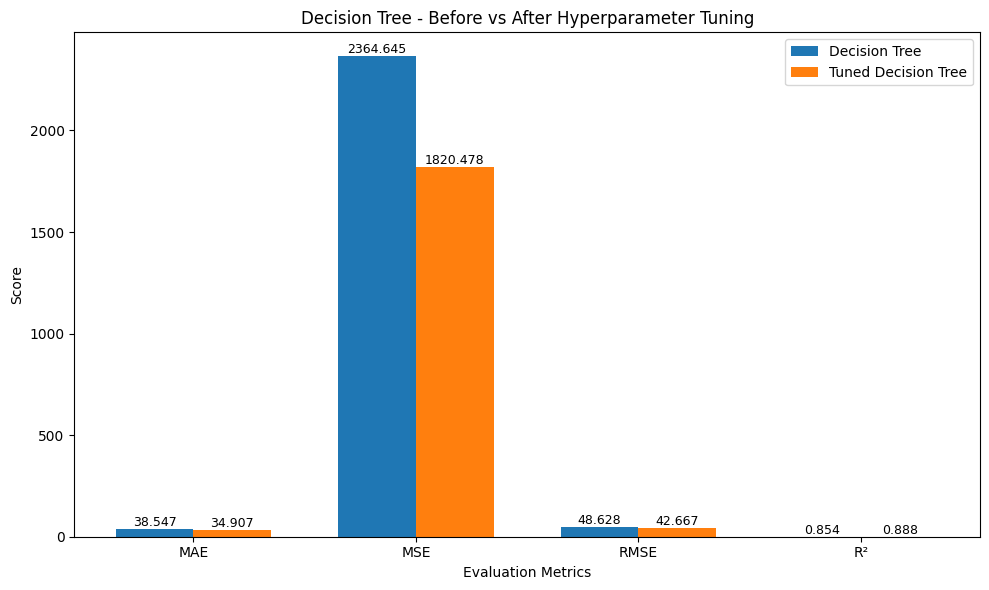

In [74]:
# Compare Decision Tree before and after tuning

metrics = ['MAE', 'MSE', 'RMSE', 'R²']

dt_scores = [
    mae_dt,
    mse_dt,
    rmse_dt,
    r2_dt
]

dt_tuned_scores = [
    mae_dt_tuned,
    mse_dt_tuned,
    rmse_dt_tuned,
    r2_dt_tuned
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    dt_scores,
    width,
    label='Decision Tree'
)

bars2 = plt.bar(
    x + width / 2,
    dt_tuned_scores,
    width,
    label='Tuned Decision Tree'
)

plt.xticks(x, metrics)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Decision Tree - Before vs After Hyperparameter Tuning")
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** was used for hyperparameter optimization.

GridSearchCV systematically evaluates different combinations of Decision Tree hyperparameters and selects the combination that provides the best cross-validation performance.

The following hyperparameters were tuned:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

**TimeSeriesSplit** was used for cross-validation because the dataset contains time-dependent stock-price observations. It maintains the chronological order of the observations and helps prevent future information from being used during model training.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, a clear improvement was observed after hyperparameter tuning of the Decision Tree Regressor.

The baseline Decision Tree and tuned Decision Tree were compared using MAE, MSE, RMSE, and R² Score.

- **MAE:** improved from `38.547` to `34.907`.
- **MSE:** improved from `2364.645` to `1820.478`.
- **RMSE:** improved from `48.628` to `42.667`.
- **R² Score:** improved from `0.854` to `0.888`.

The tuned Decision Tree achieved lower MAE, MSE, and RMSE, indicating a reduction in prediction errors. The R² Score also increased from `0.854` to `0.888`, indicating that the tuned model explains a greater proportion of the variation in the closing price.

Therefore, hyperparameter tuning significantly improved the performance of the Decision Tree Regressor on the test dataset.

### ML Model - 4: Gradient Boosting Regressor

In [75]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    random_state=42
)

# Fit the algorithm
gb_model.fit(X_train, y_train)

print("Gradient Boosting Regressor model fitted successfully.")

Gradient Boosting Regressor model fitted successfully.


In [76]:
# Predict on the test data
y_pred_gb = gb_model.predict(X_test)

# Display first 10 predictions
prediction_df_gb = pd.DataFrame({
    'Actual_Close': y_test.values,
    'Predicted_Close': y_pred_gb
})

print(prediction_df_gb.head(10))

   Actual_Close  Predicted_Close
0        315.05       328.721230
1        354.45       313.002973
2        322.25       348.965110
3        304.90       304.093517
4        362.05       326.319236
5        346.20       349.824002
6        339.60       314.290839
7        367.90       312.554797
8        343.40       350.050769
9        183.45       312.029365


In [77]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Print evaluation metrics
print("Gradient Boosting Regression - Evaluation Metrics")
print("--------------------------------------------------")
print(f"MAE  : {mae_gb:.4f}")
print(f"MSE  : {mse_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")
print(f"R²   : {r2_gb:.4f}")

Gradient Boosting Regression - Evaluation Metrics
--------------------------------------------------
MAE  : 32.5746
MSE  : 1741.0789
RMSE : 41.7262
R²   : 0.8928


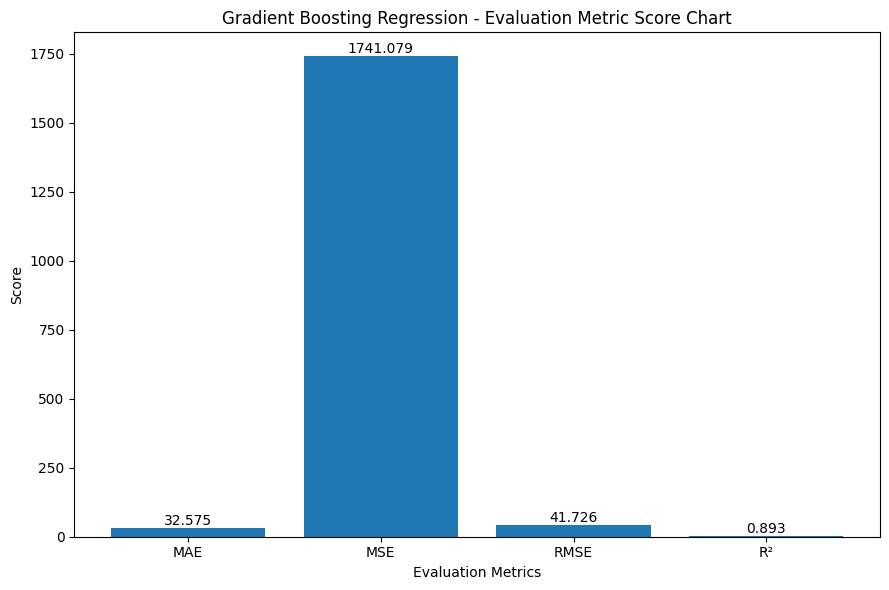

In [78]:
# Visualizing Evaluation Metric Score Chart

metrics = ['MAE', 'MSE', 'RMSE', 'R²']
scores = [mae_gb, mse_gb, rmse_gb, r2_gb]

plt.figure(figsize=(9, 6))

bars = plt.bar(metrics, scores)

plt.title("Gradient Boosting Regression - Evaluation Metric Score Chart")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

# Display values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

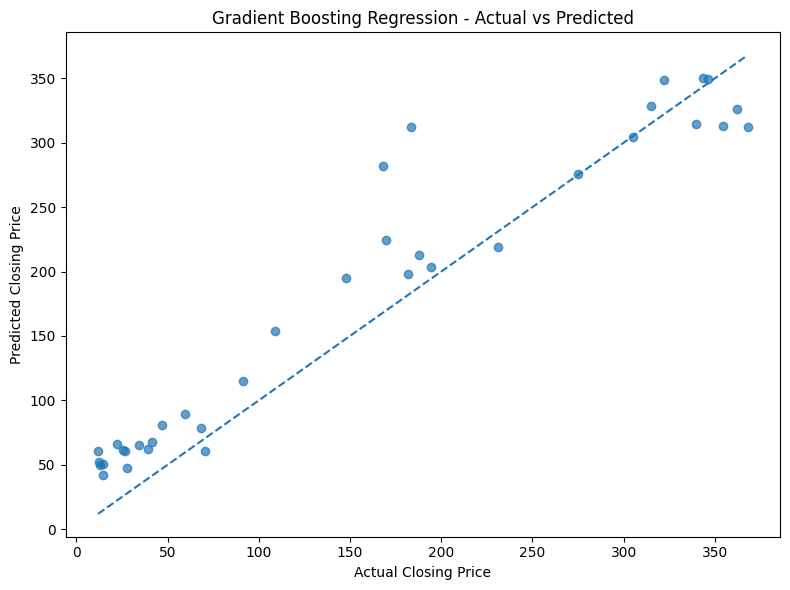

In [79]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_gb.min())
max_value = max(y_test.max(), y_pred_gb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title("Gradient Boosting Regression - Actual vs Predicted")
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")

plt.tight_layout()
plt.show()

In [80]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# Define Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

# Perform cross-validation
cv_scores_gb = cross_validate(
    gb_model,
    X_train,
    y_train,
    cv=tscv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'r2'
    ],
    n_jobs=-1
)

# Convert negative error scores to positive
cv_mae_gb = -cv_scores_gb['test_neg_mean_absolute_error']
cv_mse_gb = -cv_scores_gb['test_neg_mean_squared_error']
cv_rmse_gb = -cv_scores_gb['test_neg_root_mean_squared_error']
cv_r2_gb = cv_scores_gb['test_r2']

print("Gradient Boosting - Cross Validation")
print("-------------------------------------")
print(f"Mean MAE  : {cv_mae_gb.mean():.4f}")
print(f"Mean MSE  : {cv_mse_gb.mean():.4f}")
print(f"Mean RMSE : {cv_rmse_gb.mean():.4f}")
print(f"Mean R²   : {cv_r2_gb.mean():.4f}")

Gradient Boosting - Cross Validation
-------------------------------------
Mean MAE  : 35.7019
Mean MSE  : 3318.4663
Mean RMSE : 41.5052
Mean R²   : -1.5904


In [81]:
from sklearn.model_selection import GridSearchCV

# Create Gradient Boosting model for tuning
gb_tuning = GradientBoostingRegressor(
    random_state=42
)

# Define hyperparameter grid
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search with TimeSeriesSplit
grid_search_gb = GridSearchCV(
    estimator=gb_tuning,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit Grid Search
grid_search_gb.fit(X_train, y_train)

print("Best Hyperparameters:")
print(grid_search_gb.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search_gb.best_score_)

Best Hyperparameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

Best Cross-Validation RMSE:
39.972859482114465


In [82]:
# Get the best Gradient Boosting model
best_gb_model = grid_search_gb.best_estimator_

# Predict on test data
y_pred_gb_tuned = best_gb_model.predict(X_test)

# Calculate evaluation metrics
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
mse_gb_tuned = mean_squared_error(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mse_gb_tuned)
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)

print("Tuned Gradient Boosting - Test Performance")
print("--------------------------------------------")
print(f"MAE  : {mae_gb_tuned:.4f}")
print(f"MSE  : {mse_gb_tuned:.4f}")
print(f"RMSE : {rmse_gb_tuned:.4f}")
print(f"R²   : {r2_gb_tuned:.4f}")

Tuned Gradient Boosting - Test Performance
--------------------------------------------
MAE  : 33.4327
MSE  : 1780.5945
RMSE : 42.1971
R²   : 0.8904


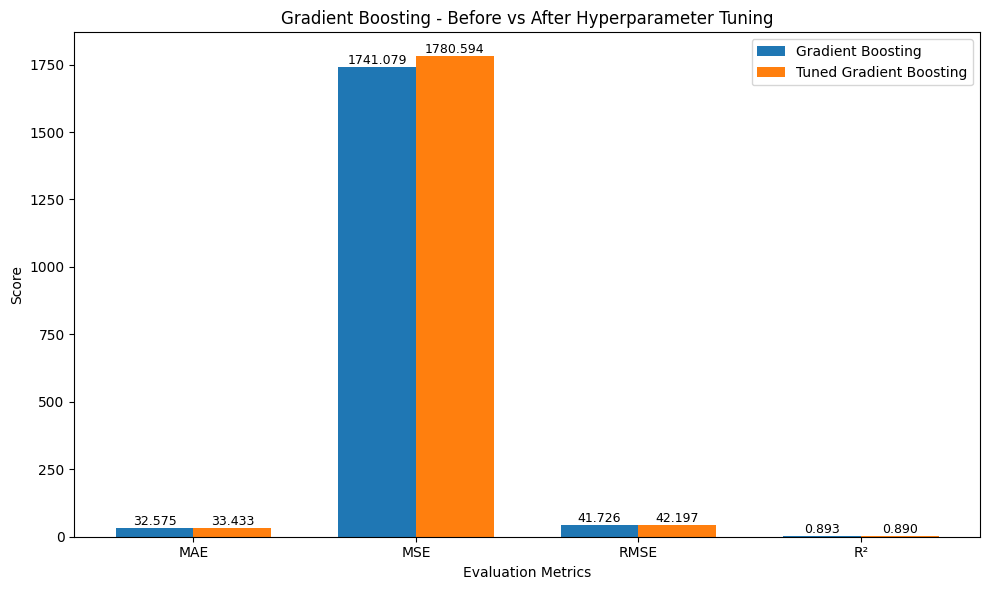

In [83]:
# Compare Gradient Boosting before and after tuning

metrics = ['MAE', 'MSE', 'RMSE', 'R²']

gb_scores = [
    mae_gb,
    mse_gb,
    rmse_gb,
    r2_gb
]

gb_tuned_scores = [
    mae_gb_tuned,
    mse_gb_tuned,
    rmse_gb_tuned,
    r2_gb_tuned
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    gb_scores,
    width,
    label='Gradient Boosting'
)

bars2 = plt.bar(
    x + width / 2,
    gb_tuned_scores,
    width,
    label='Tuned Gradient Boosting'
)

plt.xticks(x, metrics)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Gradient Boosting - Before vs After Hyperparameter Tuning")
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** was used for hyperparameter optimization.

GridSearchCV systematically evaluates different combinations of Gradient Boosting hyperparameters and selects the combination that provides the best cross-validation performance.

The following hyperparameters were tuned:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

**TimeSeriesSplit** was used for cross-validation because the dataset contains time-dependent stock-price observations. It maintains the chronological order of the observations and helps prevent future information from being used during model training.

##### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.

No significant improvement was observed after hyperparameter tuning of the Gradient Boosting Regressor.

The baseline Gradient Boosting and tuned Gradient Boosting models were compared using MAE, MSE, RMSE, and R² Score.

- **MAE:** increased from `32.575` to `33.433`.
- **MSE:** increased from `1741.079` to `1780.594`.
- **RMSE:** increased from `41.726` to `42.197`.
- **R² Score:** decreased slightly from `0.893` to `0.890`.

The tuned model produced slightly higher prediction errors and a slightly lower R² Score. Therefore, hyperparameter tuning did **not improve** the performance of the Gradient Boosting Regressor on the test dataset.

The updated Evaluation Metric Score Chart confirms that the baseline Gradient Boosting model performed slightly better than the tuned model for the current feature set and test data.

### ML Model - 5: XGBoost Regressor

In [ ]:
# !pip install xgboost

In [87]:
# XGBoost is tree-based, 
# we'll use X_train and X_test rather than the scaled versions.


from xgboost import XGBRegressor

# ML Model - 5 Implementation

# Create XGBoost Regressor
xgb_model = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

# Fit the algorithm
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model fitted successfully.")

# Predict on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Display first 10 predictions
prediction_df_xgb = pd.DataFrame({
    'Actual_Close': y_test.values,
    'Predicted_Close': y_pred_xgb
})

print(prediction_df_xgb.head(10))

XGBoost Regressor model fitted successfully.
   Actual_Close  Predicted_Close
0        315.05       343.184387
1        354.45       324.512390
2        322.25       349.856506
3        304.90       322.752747
4        362.05       343.199829
5        346.20       350.913513
6        339.60       294.087982
7        367.90       293.298767
8        343.40       350.340027
9        183.45       293.662598


In [88]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print evaluation metrics
print("XGBoost Regression - Evaluation Metrics")
print("----------------------------------------")
print(f"MAE  : {mae_xgb:.4f}")
print(f"MSE  : {mse_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

XGBoost Regression - Evaluation Metrics
----------------------------------------
MAE  : 30.9674
MSE  : 1569.9902
RMSE : 39.6231
R²   : 0.9033


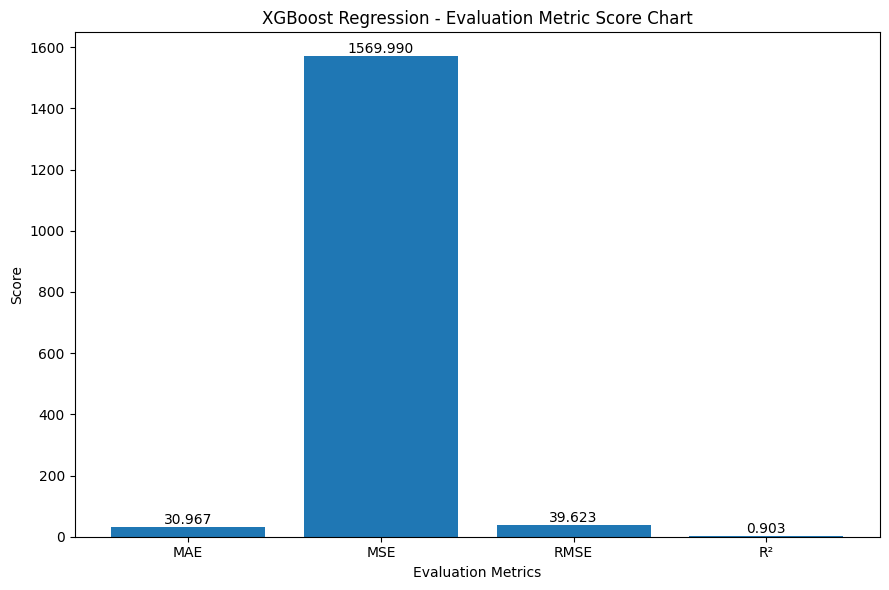

In [89]:
# Visualizing Evaluation Metric Score Chart

metrics = ['MAE', 'MSE', 'RMSE', 'R²']
scores = [mae_xgb, mse_xgb, rmse_xgb, r2_xgb]

plt.figure(figsize=(9, 6))

bars = plt.bar(metrics, scores)

plt.title("XGBoost Regression - Evaluation Metric Score Chart")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

# Display values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

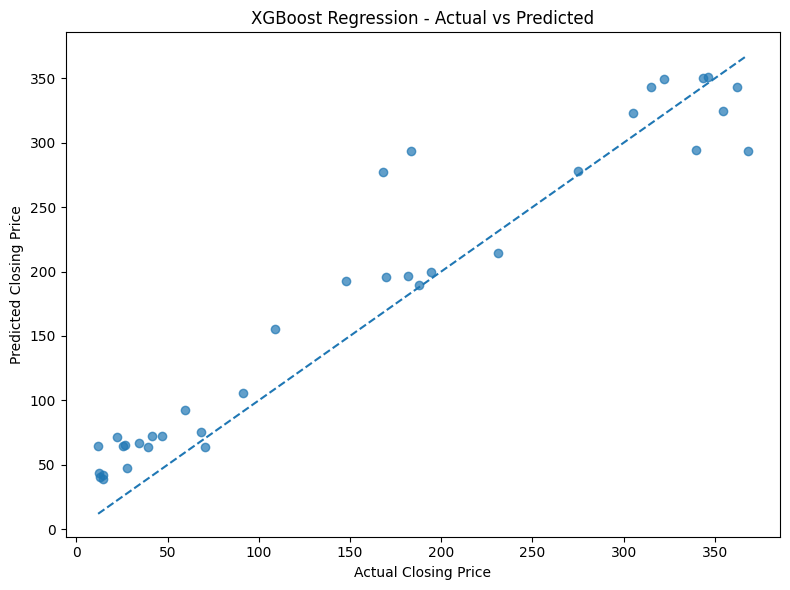

In [90]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_xgb.min())
max_value = max(y_test.max(), y_pred_xgb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title("XGBoost Regression - Actual vs Predicted")
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")

plt.tight_layout()
plt.show()

In [91]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# Define Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

# Perform cross-validation
cv_scores_xgb = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=tscv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_mean_squared_error',
        'neg_root_mean_squared_error',
        'r2'
    ],
    n_jobs=-1
)

# Convert negative error scores to positive
cv_mae_xgb = -cv_scores_xgb['test_neg_mean_absolute_error']
cv_mse_xgb = -cv_scores_xgb['test_neg_mean_squared_error']
cv_rmse_xgb = -cv_scores_xgb['test_neg_root_mean_squared_error']
cv_r2_xgb = cv_scores_xgb['test_r2']

print("XGBoost - Cross Validation")
print("--------------------------")
print(f"Mean MAE  : {cv_mae_xgb.mean():.4f}")
print(f"Mean MSE  : {cv_mse_xgb.mean():.4f}")
print(f"Mean RMSE : {cv_rmse_xgb.mean():.4f}")
print(f"Mean R²   : {cv_r2_xgb.mean():.4f}")

XGBoost - Cross Validation
--------------------------
Mean MAE  : 34.8810
Mean MSE  : 3283.4417
Mean RMSE : 40.8033
Mean R²   : -1.4063


In [92]:
from sklearn.model_selection import GridSearchCV

# Create XGBoost model for tuning
xgb_tuning = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

# Define hyperparameter grid
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid Search with TimeSeriesSplit
grid_search_xgb = GridSearchCV(
    estimator=xgb_tuning,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit Grid Search
grid_search_xgb.fit(X_train, y_train)

print("Best Hyperparameters:")
print(grid_search_xgb.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search_xgb.best_score_)

Best Hyperparameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}

Best Cross-Validation RMSE:
40.96996910617251


In [93]:
# Get the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_

# Predict on test data using tuned model
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Calculate evaluation metrics
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost - Test Performance")
print("---------------------------------")
print(f"MAE  : {mae_xgb_tuned:.4f}")
print(f"MSE  : {mse_xgb_tuned:.4f}")
print(f"RMSE : {rmse_xgb_tuned:.4f}")
print(f"R²   : {r2_xgb_tuned:.4f}")

Tuned XGBoost - Test Performance
---------------------------------
MAE  : 34.9010
MSE  : 1903.0308
RMSE : 43.6237
R²   : 0.8828


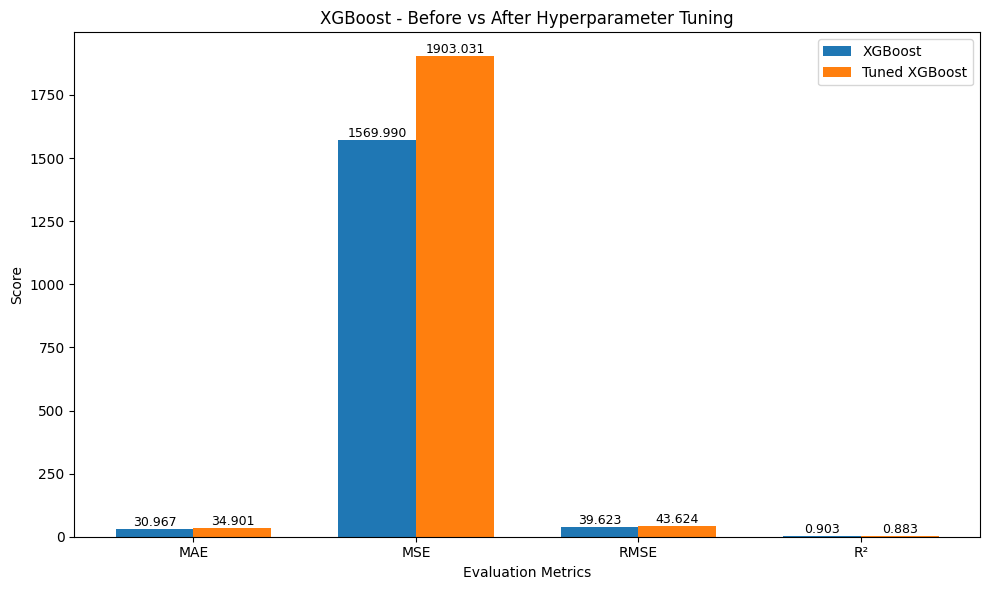

In [94]:
# Compare XGBoost before and after tuning

metrics = ['MAE', 'MSE', 'RMSE', 'R²']

xgb_scores = [
    mae_xgb,
    mse_xgb,
    rmse_xgb,
    r2_xgb
]

xgb_tuned_scores = [
    mae_xgb_tuned,
    mse_xgb_tuned,
    rmse_xgb_tuned,
    r2_xgb_tuned
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    xgb_scores,
    width,
    label='XGBoost'
)

bars2 = plt.bar(
    x + width / 2,
    xgb_tuned_scores,
    width,
    label='Tuned XGBoost'
)

plt.xticks(x, metrics)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("XGBoost - Before vs After Hyperparameter Tuning")
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** was used for hyperparameter optimization.

GridSearchCV systematically evaluates different combinations of XGBoost hyperparameters and selects the combination that provides the best cross-validation performance.

The following hyperparameters were tuned:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `subsample`
- `colsample_bytree`

**TimeSeriesSplit** was used for cross-validation because the dataset contains time-dependent stock-price observations. It maintains the chronological order of the observations and helps prevent future information from being used during model training.

##### Have you seen any improvement? Note down the improvement with updated Evaluation Metric Score Chart.

No improvement was observed after hyperparameter tuning of the XGBoost Regressor.

The baseline XGBoost and tuned XGBoost models were compared using MAE, MSE, RMSE, and R² Score.

- **MAE:** increased from `30.967` to `34.901`.
- **MSE:** increased from `1569.990` to `1903.031`.
- **RMSE:** increased from `39.623` to `43.624`.
- **R² Score:** decreased from `0.903` to `0.883`.

The tuned XGBoost model produced higher prediction errors, as indicated by the increase in MAE, MSE, and RMSE. The R² Score also decreased, indicating a reduction in the proportion of variation explained by the model.

Therefore, hyperparameter tuning did **not improve** the XGBoost model's performance on the test dataset. The baseline XGBoost model performed better for the current feature set and test data.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For evaluating the stock closing price prediction model, the following metrics were considered:

- **MAE (Mean Absolute Error):**  
  MAE was considered because it represents the average prediction error in the same unit as the stock price. A lower MAE means that the predicted closing prices are closer to the actual prices. This can help analysts make more reliable price estimates.

- **RMSE (Root Mean Squared Error):**  
  RMSE was considered because it gives greater importance to larger prediction errors. This is particularly important in stock-price prediction, where large prediction errors can have a greater financial impact. A lower RMSE indicates better control over large prediction errors.

- **R² Score:**  
  R² was considered to understand how much of the variation in the stock's closing price is explained by the model. A higher R² indicates that the model captures more of the underlying patterns in the historical data.

- **MSE (Mean Squared Error):**  
  MSE was also considered because it penalizes larger errors more strongly than MAE. It helps identify models that may occasionally make large prediction errors.

Overall, **lower MAE, MSE, and RMSE and higher R² Score** were considered indicators of better model performance and potentially greater business usefulness. These metrics together provide a balanced view of prediction accuracy and the model's ability to explain stock-price variation.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Tuned Random Forest Regressor** was selected as the final prediction model.

The model was selected based on its overall performance across the evaluation metrics:

- **MAE:** `27.452`
- **RMSE:** `38.908`
- **R² Score:** `0.907`

Among the models tested, the Tuned Random Forest achieved the **lowest MAE and RMSE** and the **highest R² Score** in the current experiment. This indicates that it produced relatively smaller prediction errors while explaining a larger proportion of the variation in the stock's closing price.

The Random Forest model can also capture **non-linear relationships** between the historical stock-price features and the target variable, making it suitable for this regression problem.

Therefore, based on the observed test-set performance, the **Tuned Random Forest Regressor** was selected as the final prediction model for this project.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [116]:
# Save the File
import joblib

# Save the best performing model
joblib.dump(best_rf_model, 'model/best_model.pkl')

print("Best performing model saved successfully.")

Best performing model saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [118]:
import joblib
import pandas as pd

# Load the saved model
loaded_model = joblib.load('model/best_model.pkl')

print("Saved model loaded successfully.")


# Select the same features used during model training
selected_features = [
    'Previous_Close',
    'Previous_Return',
    'Year'
]

X_unseen = X_test[selected_features]
y_actual = y_test


# Predict using the loaded model
y_unseen_pred = loaded_model.predict(X_unseen)

# Create comparison table
sanity_check = pd.DataFrame({
    'Actual_Close': y_actual.values,
    'Predicted_Close': y_unseen_pred
})

print(sanity_check.head(10))

Saved model loaded successfully.
   Actual_Close  Predicted_Close
0        315.05       320.336806
1        354.45       320.483278
2        322.25       331.383601
3        304.90       315.876103
4        362.05       320.103619
5        346.20       333.274591
6        339.60       324.510179
7        367.90       323.602416
8        343.40       332.424016
9        183.45       322.136447


In [119]:
# Calculate sanity-check metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Calculate metrics
sanity_mae = mean_absolute_error(y_actual, y_unseen_pred)
sanity_mse = mean_squared_error(y_actual, y_unseen_pred)
sanity_rmse = np.sqrt(sanity_mse)
sanity_r2 = r2_score(y_actual, y_unseen_pred)

print("Sanity Check Performance")
print("------------------------")
print(f"MAE  : {sanity_mae:.4f}")
print(f"MSE  : {sanity_mse:.4f}")
print(f"RMSE : {sanity_rmse:.4f}")
print(f"R²   : {sanity_r2:.4f}")

Sanity Check Performance
------------------------
MAE  : 27.4521
MSE  : 1513.8047
RMSE : 38.9076
R²   : 0.9068


In [120]:
# Check whether the loaded model gives the same predictions

# Predictions from the original trained model
original_predictions = best_rf_model.predict(X_test)

# Check whether both predictions are identical
same_predictions = np.allclose(
    original_predictions,
    y_unseen_pred
)

print("Are original and loaded-model predictions the same?")
print(same_predictions)

Are original and loaded-model predictions the same?
True


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

# **Conclusion**

- The **YES BANK Stock Price Prediction** project successfully implemented a complete machine learning workflow, including **data preprocessing, exploratory data analysis, feature engineering, feature selection, data splitting, model training, hyperparameter tuning, and model evaluation**.

- The analysis identified **Previous Close, Previous Return, and Year** as the selected features for predicting the closing price while reducing the impact of multicollinearity.

- Five regression models were evaluated:
  - Linear Regression
  - Random Forest Regressor
  - Decision Tree Regressor
  - Gradient Boosting Regressor
  - XGBoost Regressor

- Among the tested models, the **Tuned Random Forest Regressor** achieved the strongest overall performance with:
  - **MAE:** 27.452
  - **RMSE:** 38.908
  - **R²:** 0.907

- The final model was saved using **Joblib**, allowing it to be loaded later and used for predictions without retraining the model.

- Overall, this project demonstrates how historical stock-market data can be used to develop a **regression-based stock price prediction system**.

- However, the dataset contains only **185 monthly observations**, so the predictions should be interpreted carefully. The model can support analysis and learning but **cannot guarantee future stock-price movements**.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***